# Systeme VLM bidirectionnel pour la detection d'anomalies en videosurveillance

**Projet SY23** - Didi SOSSOU

---

## Objectifs
- Recherche text-to-video via embeddings CLIP
- Generation de descriptions video-to-text
- Detection temporelle d'anomalies (LSTM bidirectionnel, entrainement adversarial PGD)

## Pipeline

| Phase | Nom | Description |
|-------|-----|-------------|
| 0 | Configuration | Imports, chemins, telechargement datasets |
| 1 | Caption Generation | Generation de descriptions BDD100K via SLM (Qwen2.5-3B) |
| 2 | Fine-tuning | Fine-tuning OpenCLIP ViT-L-14 avec LoRA sur BDD100K |
| 3 | Indexation FAISS | Extraction embeddings video (UCF+CADP+DoTA) et texte enrichi |
| 4 | Entrainement MIL-PGD | Detecteur LSTM bidirectionnel avec attaques adversariales |
| 5 | Evaluation | Metriques (AUC, Precision, Recall, F1), ROC, confusion matrix |
| 6 | Demonstration | Interface Gradio (recherche, analyse, description) |

## Datasets
- **BDD100K** : 100K images urbaines avec metadonnees (weather, scene, timeofday, labels)
- **UCF-Crime** : 1854 videos (anomalies criminelles)
- **CADP** : 982 pseudo-videos (accidents de la route)
- **DoTA** : Detection of Traffic Anomaly

In [3]:
# Installation des librairies nécessaires
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
# !pip install  gradio torchaudio open_clip_torch faiss-cpu peft kagglehub tqdm matplotlib pandas numpy opencv-python pillow scikit-learn

## Configuration

Importation des librairies et configuration des chemins vers les datasets.

In [4]:
import os
import sys
import gc
import json
import pickle
import random
import shutil
import subprocess
import urllib.request
import zipfile
from pathlib import Path

import cv2
import faiss
import matplotlib.pyplot as plt
import numpy as np
import open_clip
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from peft import LoraConfig, get_peft_model
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Peripherique: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Peripherique: cuda


In [5]:
MODE = "LOCAL"

if MODE == "KAGGLE":
    BDD100K_PATH = "/kaggle/input/bdd100k"
    CAPTIONS_DIR = "/kaggle/input/captions"
    UCF_PATH = "/kaggle/input/ucaucf-crime-annotation-dataset"
    DOTA_PATH = "/kaggle/input/dota-dataset"
    CADP_PATH = "/kaggle/input/accident-detection-from-cctv-footage"
    WORKING_DIR = Path("/kaggle/working")
else:
    BDD100K_PATH = "bdd100k"
    CAPTIONS_DIR = "captions"
    UCF_PATH = "ucaucf-crime-annotation-dataset"
    DOTA_PATH = "dota-dataset"  # DoTA: Detection of Traffic Anomaly
    CADP_PATH = "cadp-dataset"  # CADP: Accident Detection CCTV
    WORKING_DIR = Path(".")

# Configuration multi-dataset
DATASETS_CONFIG = {
    "ucf_crime": {
        "path": UCF_PATH,
        "enabled": True,
        "type": "video",
        "annotations": "json",
    },
    "dota": {
        "path": DOTA_PATH,
        "enabled": Path(DOTA_PATH).exists() if MODE == "LOCAL" else True,
        "type": "frames",
        "annotations": "json",
    },
    "cadp": {
        "path": CADP_PATH,
        "enabled": Path(CADP_PATH).exists() if MODE == "LOCAL" else True,
        "type": "images",
        "annotations": "folder",
    }
}

print(f"Mode: {MODE}")
print(f"Repertoire de travail: {WORKING_DIR}")
print(f"\nDatasets configures:")
for name, cfg in DATASETS_CONFIG.items():
    status = "ACTIF" if cfg["enabled"] else "INACTIF (dossier manquant)"
    print(f"  - {name}: {status}")

Mode: LOCAL
Repertoire de travail: .

Datasets configures:
  - ucf_crime: ACTIF
  - dota: ACTIF
  - cadp: ACTIF


### Telechargement des datasets

Telechargement automatique des datasets DoTA et CADP si absents.

In [ ]:
def install_package(package):
    try:
        __import__(package)
        return True
    except ImportError:
        print(f"Installation de {package}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
            return True
        except:
            return False

def download_cadp_dataset(output_dir="cadp-dataset"):
    output_path = Path(output_dir)
    train_dir = output_path / "train"
    
    if train_dir.exists() and (train_dir / "Accident").exists():
        print(f"CADP: Dataset deja present")
        return True
    
    print("CADP: Telechargement via kagglehub (~262 MB)...")
    if not install_package("kagglehub"):
        return False
    
    import kagglehub
    try:
        downloaded_path = kagglehub.dataset_download("ckay16/accident-detection-from-cctv-footage")
        output_path.mkdir(parents=True, exist_ok=True)
        src_path = Path(downloaded_path)
        data_dir = src_path / "data" if (src_path / "data").exists() else src_path
        
        for split in ["train", "test", "val"]:
            src_split = data_dir / split
            if src_split.exists():
                dst_split = output_path / split
                if not dst_split.exists():
                    shutil.copytree(src_split, dst_split)
        
        print(f"CADP: Dataset installe")
        return True
    except Exception as e:
        print(f"Erreur CADP: {e}")
        return False

def download_dota_annotations(output_dir="dota-dataset"):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    print("DoTA: Telechargement des annotations...")
    base_url = "https://raw.githubusercontent.com/MoonBlvd/Detection-of-Traffic-Anomaly/master/dataset/"
    files = ["metadata_train.json", "metadata_val.json", "train_split.txt", "val_split.txt"]
    
    for filename in files:
        dest = output_path / filename
        if not dest.exists():
            try:
                urllib.request.urlretrieve(base_url + filename, dest)
            except:
                pass
    return (output_path / "metadata_train.json").exists()

def download_dota_frames(output_dir="dota-dataset"):
    output_path = Path(output_dir)
    frames_dir = output_path / "frames"
    
    if frames_dir.exists() and len(list(frames_dir.iterdir())) > 100:
        print(f"DoTA: Frames deja presentes ({len(list(frames_dir.iterdir()))} videos)")
        return True
    
    print("DoTA: Telechargement des frames (~55 GB)...")
    if not install_package("gdown"):
        return False
    
    import gdown
    output_path.mkdir(parents=True, exist_ok=True)
    split_folder_id = "1_WzhwZC2NIpzZIpX7YCvapq66rtBc67n"
    
    try:
        gdown.download_folder(id=split_folder_id, output=str(output_path), quiet=False)
        
        zip_files = sorted(output_path.glob("*.zip")) + sorted(output_path.glob("*.z*"))
        if zip_files:
            print(f"Extraction de {len(zip_files)} archives...")
            for zip_path in zip_files:
                if zip_path.suffix == ".zip":
                    try:
                        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                            zip_ref.extractall(output_path)
                        zip_path.unlink()
                    except:
                        pass
        
        if frames_dir.exists() and any(frames_dir.iterdir()):
            print(f"DoTA: {len(list(frames_dir.iterdir()))} videos extraites")
            return True
        return False
    except Exception as e:
        print(f"Erreur DoTA: {e}")
        return False

def download_dota_dataset(output_dir="dota-dataset"):
    download_dota_annotations(output_dir)
    return download_dota_frames(output_dir)

# Verification et telechargement automatique

cadp_valid = (Path(CADP_PATH) / "train" / "Accident").exists() if Path(CADP_PATH).exists() else False
dota_annotations_valid = (Path(DOTA_PATH) / "metadata_train.json").exists() if Path(DOTA_PATH).exists() else False
dota_frames_dir = Path(DOTA_PATH) / "frames"
dota_frames_valid = dota_frames_dir.exists() and len(list(dota_frames_dir.iterdir())) > 100 if dota_frames_dir.exists() else False

print(f"\nEtat actuel:")
print(f"  CADP: {'OK' if cadp_valid else 'Non installe'}")
print(f"  DoTA annotations: {'OK' if dota_annotations_valid else 'Non installees'}")
print(f"  DoTA frames: {'OK' if dota_frames_valid else 'Non installees'}")

if not cadp_valid:
    download_cadp_dataset(CADP_PATH)
if not dota_annotations_valid:
    download_dota_annotations(DOTA_PATH)
if not dota_frames_valid:
    download_dota_frames(DOTA_PATH)

# Mise a jour configuration
print("\n" + "="*60)
print("CONFIGURATION FINALE")
print("="*60)

cadp_valid = (Path(CADP_PATH) / "train" / "Accident").exists() if Path(CADP_PATH).exists() else False
dota_annotations_valid = (Path(DOTA_PATH) / "metadata_train.json").exists() if Path(DOTA_PATH).exists() else False
dota_frames_dir = Path(DOTA_PATH) / "frames"
dota_frames_valid = dota_frames_dir.exists() and len(list(dota_frames_dir.iterdir())) > 100 if dota_frames_dir.exists() else False

DATASETS_CONFIG["cadp"]["enabled"] = cadp_valid
DATASETS_CONFIG["dota"]["enabled"] = dota_annotations_valid and dota_frames_valid

for name, cfg in DATASETS_CONFIG.items():
    status = "ACTIF" if cfg["enabled"] else "INACTIF"
    print(f"  {name}: {status}")

VERIFICATION DES DATASETS

Etat actuel:
  CADP: OK
  DoTA annotations: OK
  DoTA frames: OK

CONFIGURATION FINALE
  ucf_crime: ACTIF
  dota: ACTIF
  cadp: ACTIF


### Chargement des annotations

Fonctions de chargement des annotations pour chaque dataset.

In [ ]:
import re

def load_dota_annotations(dota_path):
    dota_dir = Path(dota_path)
    annotations = {}
    
    if not dota_dir.exists():
        print(f"DoTA: Repertoire {dota_dir} introuvable")
        return annotations
    
    dota_class_names = {
        "ST": "vehicle suddenly stopping",
        "AH": "vehicle ahead collision",
        "LA": "lateral collision",
        "OO": "oncoming obstacle collision",
        "VO": "vehicle-obstacle collision",
        "TC": "lane change accident",
        "OC": "oncoming vehicle collision",
        "UK": "unknown traffic anomaly"
    }
    
    for split in ["train", "val"]:
        metadata_file = dota_dir / f"metadata_{split}.json"
        if not metadata_file.exists():
            continue
            
        with open(metadata_file, 'r') as f:
            split_data = json.load(f)
        
        for video_id, meta in split_data.items():
            fps = 30
            num_frames = meta.get("num_frames", 300)
            duration = num_frames / fps
            
            anomaly_start = meta.get("anomaly_start", 0)
            anomaly_end = meta.get("anomaly_end", num_frames)
            anomaly_class = meta.get("anomaly_class", "UK")
            
            start_sec = anomaly_start / fps
            end_sec = anomaly_end / fps
            
            class_desc = dota_class_names.get(anomaly_class, "traffic anomaly")
            sentence = f"Traffic surveillance showing {class_desc}"
            
            # Collecter les frames
            video_frames_dir = Path(dota_dir) / "frames" / video_id
            frames = []
            if video_frames_dir.exists():
                images_dir = video_frames_dir / "images"
                if images_dir.exists():
                    ff = sorted(images_dir.glob("*.jpg")) + sorted(images_dir.glob("*.png"))
                else:
                    ff = sorted(video_frames_dir.glob("*.jpg")) + sorted(video_frames_dir.glob("*.png"))
                frames = [str(p) for p in ff]
            
            annotations[video_id] = {
                "duration": duration,
                "timestamps": [[start_sec, end_sec]],
                "sentences": [sentence],
                "dataset": "dota",
                "anomaly_class": anomaly_class,
                "split": split,
                "frames": frames,
                "num_frames": num_frames,
                "video_id": video_id
            }
    
    print(f"DoTA: {len(annotations)} videos chargees")
    return annotations


def load_cadp_annotations(cadp_path):
    cadp_dir = Path(cadp_path)
    annotations = {}
    
    if not cadp_dir.exists():
        print(f"CADP: Repertoire {cadp_dir} introuvable")
        return annotations
    
    pattern = re.compile(r'^(.+?)\s*\((\d+)\)$')
    
    for split in ["train", "val", "test"]:
        for category in ["Accident", "Non Accident"]:
            category_dir = cadp_dir / split / category
            if not category_dir.exists():
                continue
            
            images = list(category_dir.glob("*.jpg")) + list(category_dir.glob("*.png"))
            
            video_groups = {}
            for img in images:
                name = img.stem
                match = pattern.match(name)
                
                if match:
                    prefix = match.group(1).strip()
                    frame_num = int(match.group(2))
                else:
                    prefix = name
                    frame_num = 0
                
                if prefix not in video_groups:
                    video_groups[prefix] = []
                video_groups[prefix].append((frame_num, img))
            
            is_anomaly = category == "Accident"
            cat_safe = category.replace(' ', '_')
            
            for prefix, frame_list in video_groups.items():
                frame_list.sort(key=lambda x: x[0])
                frames = [str(f[1]) for f in frame_list]
                video_id = f"cadp_{split}_{cat_safe}_{prefix}"
                num_frames = len(frames)
                duration = num_frames / 30.0
                
                annotations[video_id] = {
                    "duration": duration,
                    "timestamps": [[0, duration]] if is_anomaly else [],
                    "sentences": ["Traffic accident scene" if is_anomaly else "Normal traffic scene"],
                    "dataset": "cadp",
                    "split": split,
                    "frames": frames,
                    "is_anomaly": is_anomaly,
                    "video_id": video_id
                }
    
    n_accident = sum(1 for v in annotations.values() if v.get("is_anomaly", False))
    n_normal = len(annotations) - n_accident
    print(f"CADP: {len(annotations)} pseudo-videos ({n_accident} accidents, {n_normal} normal)")
    return annotations


def load_all_datasets():
    all_train = {}
    all_val = {}
    all_test = {}
    
    if DATASETS_CONFIG["ucf_crime"]["enabled"]:
        ucf_path = Path(UCF_PATH)
        for split, target_dict in [("Train", all_train), ("Val", all_val), ("Test", all_test)]:
            split_file = ucf_path / f"UCFCrime_{split}.json"
            if split_file.exists():
                with open(split_file, 'r') as f:
                    data = json.load(f)
                for k, v in data.items():
                    v["dataset"] = "ucf_crime"
                    v["split"] = split.lower()
                    v["video_id"] = k
                    target_dict[k] = v
        print(f"UCF-Crime: {len(all_train)} train, {len(all_val)} val, {len(all_test)} test")
    
    if DATASETS_CONFIG["dota"]["enabled"]:
        dota_annotations = load_dota_annotations(DOTA_PATH)
        for video_id, ann in dota_annotations.items():
            ann["video_id"] = video_id
            split = ann.get("split", "train")
            if split == "train":
                all_train[video_id] = ann
            else:
                all_val[video_id] = ann
    
    if DATASETS_CONFIG["cadp"]["enabled"]:
        cadp_annotations = load_cadp_annotations(CADP_PATH)
        for video_id, ann in cadp_annotations.items():
            split = ann.get("split", "train")
            if split == "train":
                all_train[video_id] = ann
            elif split == "val":
                all_val[video_id] = ann
            else:
                all_test[video_id] = ann
    
    def count_by_dataset(data):
        counts = {}
        for v in data.values():
            ds = v.get("dataset", "unknown")
            if ds not in counts:
                counts[ds] = {"normal": 0, "anomaly": 0}
            is_anom = v.get("is_anomaly", "normal" not in v.get("video_id", "").lower())
            if is_anom:
                counts[ds]["anomaly"] += 1
            else:
                counts[ds]["normal"] += 1
        return counts

    print(f"\nTotal combine:")
    print(f"  Train: {len(all_train)} videos")
    for ds, c in count_by_dataset(all_train).items():
        print(f"    - {ds}: {c['normal']} normal, {c['anomaly']} anomaly")
    print(f"  Val: {len(all_val)} videos")
    for ds, c in count_by_dataset(all_val).items():
        print(f"    - {ds}: {c['normal']} normal, {c['anomaly']} anomaly")
    print(f"  Test: {len(all_test)} videos")
    for ds, c in count_by_dataset(all_test).items():
        print(f"    - {ds}: {c['normal']} normal, {c['anomaly']} anomaly")

    return {"train": all_train, "val": all_val, "test": all_test}


all_datasets = load_all_datasets()
all_annotations = {**all_datasets['train'], **all_datasets['val'], **all_datasets['test']}
train_annotations = all_datasets['train']
val_annotations = all_datasets['val']
test_annotations = all_datasets['test']

UCF-Crime: 1165 train, 379 val, 310 test
DoTA: 4677 videos chargees
CADP: 982 pseudo-videos (455 accidents, 527 normal)

Total combine:
  Train: 5225 videos
    - ucf_crime: 589 normal, 576 anomaly
    - dota: 0 normal, 3275 anomaly
    - cadp: 422 normal, 363 anomaly
  Val: 1878 videos
    - ucf_crime: 217 normal, 162 anomaly
    - dota: 0 normal, 1402 anomaly
    - cadp: 52 normal, 45 anomaly
  Test: 410 videos
    - ucf_crime: 104 normal, 206 anomaly
    - cadp: 53 normal, 47 anomaly


### Extraction de features

Extraction des embeddings CLIP pour DoTA et CADP.

In [ ]:
def extract_dota_features(dota_path, annotations, model, preprocess, output_dir, device=DEVICE):
    dota_dir = Path(dota_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    frames_dir = dota_dir / "frames"
    if not frames_dir.exists():
        print(f"DoTA: Repertoire frames introuvable")
        return 0
    
    extracted = 0
    dota_videos = {k: v for k, v in annotations.items() if v.get("dataset") == "dota"}
    
    for video_id, ann in tqdm(dota_videos.items(), desc="DoTA features"):
        output_path = output_dir / f"{video_id}.pt"
        if output_path.exists():
            extracted += 1
            continue
        
        # Preferer la liste de frames fournie par les annotations si presente
        frame_files = []
        ann_frames = ann.get("frames", [])
        if ann_frames:
            frame_files = [Path(p) for p in ann_frames]
        else:
            video_frames_dir = frames_dir / video_id
            if not video_frames_dir.exists():
                continue
            images_dir = video_frames_dir / "images"
            if images_dir.exists():
                frame_files = sorted(images_dir.glob("*.jpg")) + sorted(images_dir.glob("*.png"))
            else:
                frame_files = sorted(video_frames_dir.glob("*.jpg")) + sorted(video_frames_dir.glob("*.png"))
        
        if not frame_files:
            continue
        
        frame_files = frame_files[::30]
        
        features_list = []
        for frame_path in frame_files:
            try:
                img = Image.open(frame_path).convert('RGB')
                img_tensor = preprocess(img).unsqueeze(0).to(device)
                with torch.no_grad():
                    feat = model.encode_image(img_tensor)
                    feat = F.normalize(feat, p=2, dim=-1)
                features_list.append(feat.cpu())
            except:
                continue
        
        if features_list:
            features = torch.cat(features_list, dim=0)
            torch.save(features, output_path)
            extracted += 1
    
    print(f"DoTA: {extracted} videos avec features")
    return extracted


def extract_cadp_features(annotations, model, preprocess, output_dir, device=DEVICE):
    """Extrait les features CLIP pour le dataset CADP avec clips de 5 frames."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    extracted = 0
    skipped = 0
    cadp_videos = {k: v for k, v in annotations.items() if v.get("dataset") == "cadp"}
    
    print(f"CADP: {len(cadp_videos)} pseudo-videos a traiter")
    
    # Debug: afficher un exemple
    first_video = next(iter(cadp_videos.items()))
    print(f"Exemple: {first_video[0]}")
    print(f"  Frames: {len(first_video[1].get('frames', []))}")
    if first_video[1].get('frames'):
        print(f"  Premier frame: {first_video[1]['frames'][0]}")
    
    for video_id, ann in tqdm(cadp_videos.items(), desc="CADP features"):
        output_path = output_dir / f"{video_id}.pt"
        if output_path.exists():
            extracted += 1
            continue
        
        frame_paths = ann.get("frames", [])
        if not frame_paths:
            skipped += 1
            continue
        
        # Grouper par clips de 5 frames
        all_clip_features = []
        clip_frames = []
        
        for frame_path in frame_paths:
            try:
                img = Image.open(frame_path).convert('RGB')
                clip_frames.append(preprocess(img))
                
                # Lorsqu'on a 5 frames, encoder le clip
                if len(clip_frames) == 5:
                    clip_tensor = torch.stack(clip_frames).to(device)
                    with torch.no_grad():
                        feat = model.encode_image(clip_tensor)
                        # Moyenner les 5 frames
                        all_clip_features.append(feat.mean(dim=0))
                    clip_frames = []
            except Exception as e:
                print(f"  Erreur frame {frame_path}: {e}")
                continue
        
        # Traiter les frames restantes si < 5
        if clip_frames:
            try:
                clip_tensor = torch.stack(clip_frames).to(device)
                with torch.no_grad():
                    feat = model.encode_image(clip_tensor)
                    all_clip_features.append(feat.mean(dim=0))
            except Exception as e:
                print(f"  Erreur clip final: {e}")
        
        if all_clip_features:
            features = torch.stack(all_clip_features)
            features = F.normalize(features, p=2, dim=-1)
            torch.save(features.cpu(), output_path)
            extracted += 1
        else:
            skipped += 1
    
    print(f"CADP: {extracted} pseudo-videos extraites, {skipped} ignorees")
    return extracted


def extract_all_dataset_features(model, preprocess, annotations_dict, device=DEVICE):
    """Extrait les features pour tous les datasets actifs."""
    output_dir = WORKING_DIR / "video_embeddings"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    all_annotations = {}
    for split_data in annotations_dict.values():
        all_annotations.update(split_data)
    
    print(f"\nTotal annotations: {len(all_annotations)}")
    
    dataset_counts = {}
    for video_id, ann in all_annotations.items():
        ds = ann.get("dataset", "unknown")
        if ds not in dataset_counts:
            dataset_counts[ds] = {"total": 0, "extracted": 0}
        dataset_counts[ds]["total"] += 1
        
        feat_path = output_dir / f"{video_id}.pt"
        if feat_path.exists():
            dataset_counts[ds]["extracted"] += 1
    
    print("\nStatut des features:")
    for ds, counts in dataset_counts.items():
        pct = counts["extracted"] / counts["total"] * 100 if counts["total"] > 0 else 0
        print(f"  {ds}: {counts['extracted']}/{counts['total']} ({pct:.1f}%)")
    
    if DATASETS_CONFIG.get("dota", {}).get("enabled", False):
        dota_counts = dataset_counts.get("dota", {"total": 0, "extracted": 0})
        if dota_counts["extracted"] < dota_counts["total"]:
            print("\nExtraction DoTA...")
            extract_dota_features(DOTA_PATH, all_annotations, model, preprocess, output_dir, device)
    
    if DATASETS_CONFIG.get("cadp", {}).get("enabled", False):
        cadp_counts = dataset_counts.get("cadp", {"total": 0, "extracted": 0})
        if cadp_counts["extracted"] < cadp_counts["total"]:
            print("\nExtraction CADP...")
            extract_cadp_features(all_annotations, model, preprocess, output_dir, device)
    
    print("\n" + "="*40)
    print("FEATURES FINALES")
    print("="*40)
    
    for ds in dataset_counts:
        count = sum(1 for v, a in all_annotations.items() 
                   if a.get("dataset") == ds and (output_dir / f"{v}.pt").exists())
        total = dataset_counts[ds]["total"]
        print(f"  {ds}: {count}/{total}")
    
    return True

In [9]:
# Déterminer si l'extraction multi-dataset doit être activée
if MODE == "KAGGLE" or any(DATASETS_CONFIG.get(ds, {}).get("enabled", False)
                          for ds in ["dota", "cadp"]):
    print("Extraction des features activee")
    EXTRACT_MULTI_FEATURES = True
else:
    print("Features deja extraites")
    EXTRACT_MULTI_FEATURES = False

Extraction des features activee


## Phase 0 : Exploration des donnees

In [10]:
def show_random_images_from_folder(folder, n=8):
    images = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample = random.sample(images, min(n, len(images)))
    plt.figure(figsize=(20, 5))
    for i, img_name in enumerate(sample):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_name)
    plt.show()

def sample_captions(captions_dir, n=5):
    caption_files = [f for f in os.listdir(captions_dir) if f.endswith('.json')]
    sample = random.sample(caption_files, min(n, len(caption_files)))
    for file in sample:
        with open(os.path.join(captions_dir, file), 'r', encoding='utf-8') as f:
            data = json.load(f)
            print(f"Fichier: {file}")
            for k, v in list(data.items())[:3]:
                print(f"{k}: {v}")
            print("-"*40)

def sample_ucf_videos(ucf_path, n=5):
    if not os.path.exists(ucf_path):
        print("Repertoire UCF introuvable.")
        return
    classes = [d for d in os.listdir(ucf_path) if os.path.isdir(os.path.join(ucf_path, d))]
    print(f"Classes UCF: {len(classes)}")
    for c in random.sample(classes, min(n, len(classes))):
        class_dir = os.path.join(ucf_path, c)
        videos = [f for f in os.listdir(class_dir) if f.endswith('.avi')]
        if videos:
            vid = random.choice(videos)
            print(f"Classe: {c}, Video: {vid}")

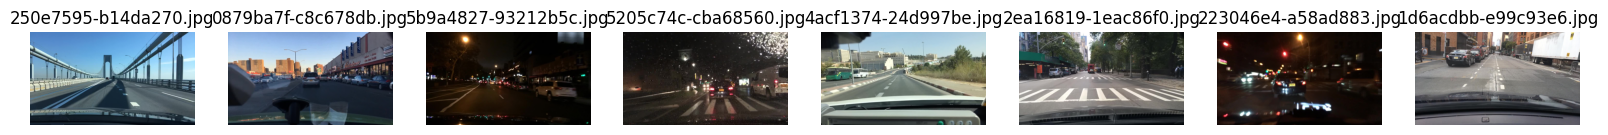

Fichier: urban_captions_val.json
b1c66a42-6f7d68ca.jpg: A busy city street with overcast skies and traffic lights displaying various colors, with drivers navigating through lanes marked by crosswalks, single yellow, and road curbs.
b1c81faa-3df17267.jpg: A clear night highway with two cars on alternate lanes, traffic lights green and yellow, and a single white road curb visible.
b1c81faa-c80764c5.jpg: A clear night highway with 11 cars on the same lane, all drivable directly or via an alternate route.
----------------------------------------
Fichier: urban_captions_train__.json
0000f77c-6257be58.jpg: Two cars drive slowly on a city street with clear weather, traffic lights green at an intersection marked by road curbs and lane lines.
0000f77c-62c2a288.jpg: Dawn light filters through early morning mist as single-lane highway stretches ahead, bordered by undulating farmland; occasional dust devils hint at heat rising from the dry earth.
0000f77c-cb820c98.jpg: Dawn light filters through r

In [11]:
bdd_images_dir = os.path.join(BDD100K_PATH, "train", "images")
if os.path.exists(bdd_images_dir):
    show_random_images_from_folder(bdd_images_dir, n=8)

if os.path.exists(CAPTIONS_DIR):
    sample_captions(CAPTIONS_DIR, n=5)

ucf_videos_dir = os.path.join(UCF_PATH, "UCF_Crimes", "UCF_Crimes", "Videos")
sample_ucf_videos(ucf_videos_dir, n=5)

## Phase 1 : Generation de captions BDD100K via SLM

Transformation des metadonnees BDD100K structurees (JSON) en descriptions naturelles via un Small Language Model (SLM) quantifie 4-bit.

**Modele** : Qwen2.5-3B-Instruct (quantification 4-bit via bitsandbytes, ~2GB VRAM)

**Entree** : Metadonnees BDD100K
- `attributes` : weather, scene, timeofday
- `labels` : objects (car, person, truck, bus, rider, bike, motor, train)
- `traffic_light` : couleur (red, yellow, green)
- `lane` : type (crosswalk, double yellow, single white, etc.)
- `drivable_area` : type (direct, alternative)

**Sortie** : Descriptions naturelles pour fine-tuning CLIP

### Installation des dependances SLM

In [12]:
# Installation des dependances pour le SLM (a executer une seule fois)
# !pip install transformers>=4.36.0 bitsandbytes>=0.41.0 accelerate>=0.25.0 sentencepiece

### Chargement du SLM quantifie

In [13]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Modele plus petit = plus rapide (0.5B au lieu de 3B)
SLM_MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
CAPTION_BATCH_SIZE = 100
CAPTION_OUTPUT_DIR = Path(CAPTIONS_DIR)
CAPTION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load_slm_model():
    """Charge le SLM - version 0.5B sans quantification (assez petit)."""
    print(f"Chargement du SLM: {SLM_MODEL_ID}")
    
    slm_tokenizer = AutoTokenizer.from_pretrained(SLM_MODEL_ID, trust_remote_code=True)
    slm_model = AutoModelForCausalLM.from_pretrained(
        SLM_MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True
    )
    
    print(f"SLM charge sur {next(slm_model.parameters()).device}")
    return slm_model, slm_tokenizer

def clear_slm_from_memory(slm_model, slm_tokenizer):
    """Libere la memoire GPU apres generation des captions."""
    del slm_model
    del slm_tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("Memoire GPU liberee (SLM decharge)")

### Parseur de metadonnees BDD100K

In [14]:
def parse_bdd100k_metadata(image_data):
    """
    Parse les metadonnees BDD100K pour une image et retourne un dictionnaire structure.
    
    Args:
        image_data: Dictionnaire contenant les annotations d'une image BDD100K
        
    Returns:
        dict: Metadonnees parsees (weather, scene, timeofday, objects, traffic_lights, lanes)
    """
    metadata = {
        "weather": "unknown",
        "scene": "unknown", 
        "timeofday": "unknown",
        "objects": {},
        "traffic_lights": [],
        "lanes": [],
        "drivable_areas": []
    }
    
    # Attributs globaux
    attributes = image_data.get("attributes", {})
    metadata["weather"] = attributes.get("weather", "unknown")
    metadata["scene"] = attributes.get("scene", "unknown")
    metadata["timeofday"] = attributes.get("timeofday", "unknown")
    
    # Labels (objets, feux, voies)
    labels = image_data.get("labels", [])
    
    for label in labels:
        category = label.get("category", "")
        
        # Objets detectables (vehicules, personnes)
        if category in ["car", "truck", "bus", "train", "motorcycle", "bicycle", "pedestrian", "rider"]:
            if category not in metadata["objects"]:
                metadata["objects"][category] = 0
            metadata["objects"][category] += 1
            
        # Feux de signalisation
        elif category == "traffic light":
            attrs = label.get("attributes", {})
            color = attrs.get("trafficLightColor", "unknown")
            metadata["traffic_lights"].append(color)
            
        # Marquages au sol / voies
        elif category == "lane":
            attrs = label.get("attributes", {})
            lane_info = {
                "type": attrs.get("laneType", "unknown"),
                "style": attrs.get("laneStyle", "unknown")
            }
            metadata["lanes"].append(lane_info)
            
        # Zones praticables
        elif category == "drivable area":
            attrs = label.get("attributes", {})
            area_type = attrs.get("areaType", "unknown")
            if area_type not in metadata["drivable_areas"]:
                metadata["drivable_areas"].append(area_type)
    
    return metadata


def format_metadata_for_slm(metadata):
    """
    Formate les metadonnees parsees en prompt structure pour le SLM.
    
    Args:
        metadata: Dictionnaire retourne par parse_bdd100k_metadata
        
    Returns:
        str: Prompt formate pour le SLM
    """
    lines = []
    
    # Conditions
    lines.append(f"Weather: {metadata['weather']}")
    lines.append(f"Scene: {metadata['scene']}")
    lines.append(f"Time: {metadata['timeofday']}")
    
    # Objets
    if metadata["objects"]:
        obj_str = ", ".join([f"{count} {obj}{'s' if count > 1 else ''}" 
                            for obj, count in metadata["objects"].items()])
        lines.append(f"Objects: {obj_str}")
    else:
        lines.append("Objects: none visible")
    
    # Feux
    if metadata["traffic_lights"]:
        from collections import Counter
        light_counts = Counter(metadata["traffic_lights"])
        light_str = ", ".join([f"{count} {color}" for color, count in light_counts.items()])
        lines.append(f"Traffic lights: {light_str}")
    
    # Voies
    if metadata["lanes"]:
        lane_types = list(set([l["type"] for l in metadata["lanes"] if l["type"] != "unknown"]))
        if lane_types:
            lines.append(f"Lane markings: {', '.join(lane_types)}")
    
    # Zones
    if metadata["drivable_areas"]:
        lines.append(f"Drivable areas: {', '.join(metadata['drivable_areas'])}")
    
    return "\n".join(lines)

### Generation de captions par batch

In [ ]:
def build_prompt(metadata_str, slm_tokenizer):
    """Construit le prompt pour une image."""
    system_prompt = "Generate a single concise sentence (under 25 words) describing this driving scene. No preamble."
    user_prompt = f"{metadata_str}\nDescription:"
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    return slm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def generate_captions_batched(slm_model, slm_tokenizer, annotations_data, output_file, inference_batch_size=16, save_every=500):
    """
    Generation de captions avec batching GPU pour acceleration.
    
    Args:
        slm_model: Modele SLM
        slm_tokenizer: Tokenizer
        annotations_data: Liste des annotations BDD100K
        output_file: Fichier de sortie JSON
        inference_batch_size: Nombre d'images traitees simultanement par le GPU
        save_every: Frequence de sauvegarde
    """
    captions = {}
    output_path = Path(output_file)
    
    if output_path.exists():
        with open(output_path, 'r', encoding='utf-8') as f:
            captions = json.load(f)
        print(f"Reprise: {len(captions)} captions existantes")
    
    # Filtrer les images deja traitees
    to_process = [img for img in annotations_data if img["name"] not in captions]
    print(f"A traiter: {len(to_process)} / {len(annotations_data)}")
    
    if not to_process:
        print("Toutes les captions sont deja generees.")
        return captions
    
    if slm_tokenizer.pad_token is None:
        slm_tokenizer.pad_token = slm_tokenizer.eos_token
    slm_tokenizer.padding_side = "left"
    
    # Traitement par batch
    total_batches = (len(to_process) + inference_batch_size - 1) // inference_batch_size
    
    for batch_idx in tqdm(range(total_batches), desc="Generation captions (batched)"):
        start_idx = batch_idx * inference_batch_size
        end_idx = min(start_idx + inference_batch_size, len(to_process))
        batch_data = to_process[start_idx:end_idx]
        prompts = []
        img_names = []
        fallbacks = []
        
        for img_data in batch_data:
            img_name = img_data["name"]
            img_names.append(img_name)
            
            try:
                metadata = parse_bdd100k_metadata(img_data)
                metadata_str = format_metadata_for_slm(metadata)
                prompt = build_prompt(metadata_str, slm_tokenizer)
                prompts.append(prompt)
                fallbacks.append(None)
            except Exception as e:
                attrs = img_data.get("attributes", {})
                fallback = f"A {attrs.get('weather', 'clear')} {attrs.get('timeofday', 'daytime')} scene in {attrs.get('scene', 'city street')}."
                prompts.append(None)
                fallbacks.append(fallback)
        
        # Filtrer les prompts valides
        valid_indices = [i for i, p in enumerate(prompts) if p is not None]
        valid_prompts = [prompts[i] for i in valid_indices]
        
        if valid_prompts:
            inputs = slm_tokenizer(
                valid_prompts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512
            ).to(slm_model.device)
            
            with torch.no_grad():
                outputs = slm_model.generate(
                    **inputs,
                    max_new_tokens=40,
                    do_sample=False,
                    pad_token_id=slm_tokenizer.pad_token_id,
                    eos_token_id=slm_tokenizer.eos_token_id,
                )
            
            input_lengths = inputs["input_ids"].shape[1]
            generated_texts = slm_tokenizer.batch_decode(
                outputs[:, input_lengths:],
                skip_special_tokens=True
            )
            
            for i, gen_idx in enumerate(valid_indices):
                caption = generated_texts[i].strip()
                if len(caption) > 200:
                    caption = caption[:200] + "..."
                if not caption:
                    attrs = batch_data[gen_idx].get("attributes", {})
                    caption = f"A {attrs.get('weather', 'clear')} {attrs.get('timeofday', 'daytime')} driving scene."
                captions[img_names[gen_idx]] = caption
        
        for i, fb in enumerate(fallbacks):
            if fb is not None:
                captions[img_names[i]] = fb
        
        if (batch_idx + 1) % max(1, save_every // inference_batch_size) == 0:
            with open(output_path, 'w', encoding='utf-8') as f:
                json.dump(captions, f, indent=2, ensure_ascii=False)
            print(f"Sauvegarde: {len(captions)} captions")
    
    # Sauvegarde finale
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(captions, f, indent=2, ensure_ascii=False)
    print(f"Termine: {len(captions)} captions")
    
    return captions

### Execution de la generation de captions

Cette cellule execute le pipeline complet de generation. En mode LOCAL, si les captions existent deja, cette etape est sautee.

In [ ]:
BDD_ANNOTATIONS_TRAIN = Path(BDD100K_PATH) / "train" / "annotations" / "bdd100k_labels_images_train.json"
BDD_ANNOTATIONS_VAL = Path(BDD100K_PATH) / "val" / "annotations" / "bdd100k_labels_images_val.json"

CAPTIONS_TRAIN_FILE = CAPTION_OUTPUT_DIR / "urban_captions_train.json"
CAPTIONS_VAL_FILE = CAPTION_OUTPUT_DIR / "urban_captions_val.json"
INFERENCE_BATCH_SIZE = 32
existing_train_count = 0
existing_val_count = 0

if CAPTIONS_TRAIN_FILE.exists():
    with open(CAPTIONS_TRAIN_FILE, 'r', encoding='utf-8') as f:
        existing_train_count = len(json.load(f))
if CAPTIONS_VAL_FILE.exists():
    with open(CAPTIONS_VAL_FILE, 'r', encoding='utf-8') as f:
        existing_val_count = len(json.load(f))

print(f"Captions existantes: {existing_train_count} train, {existing_val_count} val")

if not BDD_ANNOTATIONS_TRAIN.exists():
    print(f"ERREUR: Annotations BDD100K introuvables: {BDD_ANNOTATIONS_TRAIN}")
else:
    with open(BDD_ANNOTATIONS_TRAIN, 'r', encoding='utf-8') as f:
        bdd_train_data = json.load(f)
    
    if BDD_ANNOTATIONS_VAL.exists():
        with open(BDD_ANNOTATIONS_VAL, 'r', encoding='utf-8') as f:
            bdd_val_data = json.load(f)
    else:
        bdd_val_data = []
    
    train_done = existing_train_count >= len(bdd_train_data)
    val_done = existing_val_count >= len(bdd_val_data) if bdd_val_data else True
    
    if train_done and val_done:
        print("Phase 1 : Toutes les captions sont deja generees. SKIP.")
    else:
        print(f"A generer: {len(bdd_train_data) - existing_train_count} train, {len(bdd_val_data) - existing_val_count} val")
        
        if 'slm_model' not in dir() or slm_model is None:
            slm_model, slm_tokenizer = load_slm_model()
        if not train_done:
            print(f"\n--- Generation captions TRAIN (batch_size={INFERENCE_BATCH_SIZE}) ---")
            captions_train = generate_captions_batched(
                slm_model, slm_tokenizer, 
                bdd_train_data, 
                CAPTIONS_TRAIN_FILE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
                save_every=500
            )
        
        # Generer les captions val
        if bdd_val_data and not val_done:
            print(f"\n--- Generation captions VAL (batch_size={INFERENCE_BATCH_SIZE}) ---")
            captions_val = generate_captions_batched(
                slm_model, slm_tokenizer, 
                bdd_val_data, 
                CAPTIONS_VAL_FILE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
                save_every=200
            )
        
        clear_slm_from_memory(slm_model, slm_tokenizer)
        slm_model = None
        slm_tokenizer = None
        
        print("\nPhase 1 : Generation de captions TERMINEE")

Captions existantes: 69863 train, 10000 val
Phase 1 : Toutes les captions sont deja generees. SKIP.


## Phase 2 : Fine-tuning OpenCLIP

Fine-tuning contrastif LoRA sur BDD100K avec les captions generees en Phase 1.

In [17]:
open_clip.list_pretrained()

[('RN50', 'openai'),
 ('RN50', 'yfcc15m'),
 ('RN50', 'cc12m'),
 ('RN101', 'openai'),
 ('RN101', 'yfcc15m'),
 ('RN50x4', 'openai'),
 ('RN50x16', 'openai'),
 ('RN50x64', 'openai'),
 ('ViT-B-32', 'openai'),
 ('ViT-B-32', 'laion400m_e31'),
 ('ViT-B-32', 'laion400m_e32'),
 ('ViT-B-32', 'laion2b_e16'),
 ('ViT-B-32', 'laion2b_s34b_b79k'),
 ('ViT-B-32', 'datacomp_xl_s13b_b90k'),
 ('ViT-B-32', 'datacomp_m_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_image_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_text_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_s128m_b4k'),
 ('ViT-B-32', 'datacomp_s_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_image_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_text_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_s13m_b4k'),
 ('ViT-

In [ ]:
class BDD100KPrecomputedDataset(Dataset):
    """Dataset pour BDD100K utilisant les captions generees.

    Charge images depuis BDD100K_PATH/<split>/images et captions depuis CAPTIONS_{split.upper()}_FILE
    Retourne (image_tensor, caption_str).
    """
    def __init__(self, split='train', transform=None):
        self.split = split
        self.img_dir = Path(BDD100K_PATH) / split / 'images'
        self.caption_file = CAPTIONS_TRAIN_FILE if split == 'train' else CAPTIONS_VAL_FILE
        self.transform = transform

        if not self.img_dir.exists():
            raise FileNotFoundError(f"BDD100K images introuvables: {self.img_dir}")
        if not self.caption_file.exists():
            raise FileNotFoundError(f"BDD100K captions introuvables: {self.caption_file}")

        with open(self.caption_file, 'r', encoding='utf-8') as f:
            self.captions_map = json.load(f)

        self.img_names = [n for n in self.captions_map.keys() if (self.img_dir / n).exists()]
        if not self.img_names:
            raise RuntimeError(f"Aucune image trouvee correspondant aux captions dans {self.img_dir}")
        print(f"BDD100K {split}: {len(self.img_names)} images found")

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        caption = self.captions_map[img_name]
        img_path = self.img_dir / img_name
        image = cv2.imread(str(img_path))
        if image is None:
            return torch.zeros(3, 224, 224), ""
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, caption

In [ ]:
MODEL_TYPE = 'ViT-L-14'
PRETRAINED = 'laion400m_e32'
SUBSET_SIZE = 1000
BATCH_SIZE = 32

USE_QUANT_VLM = True  
def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()

def apply_lora_to_clip(model):
    config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["c_fc", "c_proj"],
        lora_dropout=0.05,
        bias="none"
    )
    model = get_peft_model(model, config)
    return model

# Entrainement finetune
def train_vlm_phase_0(model, tokenizer, loader, epochs=1):
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
    scaler = torch.amp.GradScaler()
    loss_fn = torch.nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"Phase 2 (LoRA+Quant) - Epoch {epoch+1}")
        for images, texts in pbar:
            images = images.to(DEVICE, non_blocking=True)
            texts = tokenizer(texts).to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16 if DEVICE.startswith('cuda') else torch.float32):
                img_feat, txt_feat, scale = model(images, texts)
                logits_img = scale * img_feat @ txt_feat.t()
                logits_txt = logits_img.t()
                ground_truth = torch.arange(len(images), device=DEVICE)
                total_loss = (loss_fn(logits_img, ground_truth) + loss_fn(logits_txt, ground_truth)) / 2
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()
            pbar.set_postfix(loss=f"{total_loss.item():.4f}")

clear_gpu()


# Charger le modele OpenCLIP et tokenizer
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_TYPE, pretrained=PRETRAINED)
tokenizer = open_clip.get_tokenizer(MODEL_TYPE)

model = apply_lora_to_clip(model)
model.to(DEVICE)
print(f"OpenCLIP {MODEL_TYPE} charge (LoRA){' + quant' if USE_QUANT_VLM else ''}")

if not CAPTIONS_TRAIN_FILE.exists():
    raise RuntimeError(f"Captions BDD100K introuvables: {CAPTIONS_TRAIN_FILE}")

full_dataset = BDD100KPrecomputedDataset(split="train", transform=preprocess)
indices = torch.randperm(len(full_dataset))[:SUBSET_SIZE]
subset_dataset = torch.utils.data.Subset(full_dataset, indices)

loader = DataLoader(
    subset_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

# Lancer le fine-tuning
train_vlm_phase_0(model, tokenizer, loader, epochs=12)
torch.save(model.state_dict(), str(WORKING_DIR / "vlm_phase0_finetuned.pth"))
model.eval()
print(f"Phase 2 terminee. Modele sauvegarde.")

for param in model.parameters():
    param.requires_grad = False

OpenCLIP ViT-L-14 charge (LoRA) + quant
BDD100K train: 69863 images found


Phase 2 (LoRA+Quant) - Epoch 1:   0%|          | 0/31 [00:00<?, ?it/s]

## Phase 3 : Indexation FAISS

Extraction et indexation des embeddings video (UCF+CADP+DoTA) et texte enrichi (descriptions + requetes).

### 3.1 Annotations UCF-Crime

In [ ]:
uca_train_path = Path(UCF_PATH) / "UCFCrime_Train.json"
uca_test_path = Path(UCF_PATH) / "UCFCrime_Test.json"
uca_val_path = Path(UCF_PATH) / "UCFCrime_Val.json"

uca_train, uca_test, uca_val = {}, {}, {}

if uca_train_path.exists():
    with open(uca_train_path, 'r') as f:
        uca_train = json.load(f)

if uca_test_path.exists():
    with open(uca_test_path, 'r') as f:
        uca_test = json.load(f)

if uca_val_path.exists():
    with open(uca_val_path, 'r') as f:
        uca_val = json.load(f)

uca_full = {**uca_train, **uca_test, **uca_val}
print(f"UCF-Crime: {len(uca_train)} train, {len(uca_val)} val, {len(uca_test)} test")

UCF-Crime: 1165 train, 379 val, 310 test


### 3.2 Index FAISS video

In [ ]:
EMBED_DIM = model.visual.output_dim
OUTPUT_FEAT_DIR = WORKING_DIR / "video_embeddings"
INDEX_VIDEO_PATH = WORKING_DIR / "ucf_video_index.faiss"
VIDEO_PATHS_PKL = WORKING_DIR / "video_paths.pkl"

# Fonction d'extraction de features video
def extract_video_features(video_path, model, preprocess):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_per_clip = int(fps * 5)
    
    if total_frames <= 0: 
        cap.release()
        return torch.zeros(1, EMBED_DIM).to(DEVICE)
    
    all_clip_features = []
    for start_frame in range(0, total_frames, frames_per_clip):
        end_frame = min(start_frame + frames_per_clip, total_frames)
        if (end_frame - start_frame) < frames_per_clip * 0.5: 
            break
        
        indices = np.linspace(start_frame, end_frame - 1, 5).astype(int)
        clip_frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                clip_frames.append(preprocess(Image.fromarray(frame)))
        
        if len(clip_frames) == 5:
            clip_tensor = torch.stack(clip_frames).to(DEVICE)
            with torch.no_grad():
                feat = model.encode_image(clip_tensor)
                all_clip_features.append(feat.mean(dim=0))
    
    cap.release()
    if not all_clip_features: 
        return torch.zeros(1, EMBED_DIM).to(DEVICE)
    
    features_tensor = torch.stack(all_clip_features)
    return F.normalize(features_tensor, p=2, dim=-1)

if MODE == "LOCAL" and INDEX_VIDEO_PATH.exists() and VIDEO_PATHS_PKL.exists():
    print("Chargement de l'index video...")
    
    index_video = faiss.read_index(str(INDEX_VIDEO_PATH))
    with open(VIDEO_PATHS_PKL, "rb") as f:
        video_paths_list = pickle.load(f)
    
    assert index_video.d == EMBED_DIM, f"Dimension incompatible: index={index_video.d}, modele={EMBED_DIM}"
    print(f"Index video: {index_video.ntotal} videos")
    
else:
    print("Extraction et indexation des features video...")
    OUTPUT_FEAT_DIR.mkdir(parents=True, exist_ok=True)
    
    model_weights = WORKING_DIR / "vlm_phase0_finetuned.pth"
    if model_weights.exists():
        print(f"Chargement des poids fine-tunes: {model_weights}")
        model.load_state_dict(torch.load(model_weights, map_location=DEVICE))
    else:
        print("Poids fine-tunes introuvables, utilisation du modele pre-entraine")
    
    model.to(DEVICE)
    model.eval()
    
    index_video = faiss.IndexFlatIP(EMBED_DIM)
    video_files = list(Path(UCF_PATH).rglob("*.mp4"))
    video_paths_list = []
    
    print(f"Extraction des features de {len(video_files)} videos")
    
    for v_path in tqdm(video_files, desc="Features video"):
        feat_save_path = OUTPUT_FEAT_DIR / (v_path.stem + ".pt")
        
        if feat_save_path.exists():
            feats = torch.load(feat_save_path, map_location=DEVICE)
        else:
            feats = extract_video_features(v_path, model, preprocess)
            torch.save(feats.cpu(), feat_save_path)
        
        mean_feat = feats.mean(dim=0).cpu().numpy().astype('float32')
        if mean_feat.shape[0] == EMBED_DIM:
            faiss.normalize_L2(mean_feat.reshape(1, -1))
            index_video.add(mean_feat.reshape(1, -1))
            video_paths_list.append(str(v_path))
    
    faiss.write_index(index_video, str(INDEX_VIDEO_PATH))

Extraction et indexation des features video...
ATTENTION: Poids fine-tunes introuvables, utilisation du modele pre-entraine
Extraction des features de 1950 videos


Features video: 100%|██████████| 1950/1950 [00:40<00:00, 47.82it/s]


### 3.3 Index FAISS texte

Embeddings des descriptions UCF-Crime pour recherche semantique.

In [ ]:
TEXT_OUTPUT_DIR = WORKING_DIR / "text_embeddings"
INDEX_TEXT_PATH = WORKING_DIR / "index_text_full.faiss"
TEXT_DB_PKL = WORKING_DIR / "text_database.pkl"

if MODE == "LOCAL" and INDEX_TEXT_PATH.exists() and TEXT_DB_PKL.exists():
    index_text = faiss.read_index(str(INDEX_TEXT_PATH))
    with open(TEXT_DB_PKL, "rb") as f:
        text_database = pickle.load(f)
    
    if index_text.ntotal != len(text_database):
        min_size = min(index_text.ntotal, len(text_database))
        if len(text_database) > min_size:
            text_database = text_database[:min_size]
    
    print(f"Index texte: {index_text.ntotal} descriptions")
    
else:
    print("Extraction et indexation des features texte...")
    TEXT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    index_text = faiss.IndexFlatIP(EMBED_DIM)
    text_database = []
    
    # Utiliser all_annotations si disponible (multi-dataset), sinon uca_full
    annotations_source = all_annotations if 'all_annotations' in dir() and all_annotations else uca_full
    
    for video_name, annotations in tqdm(annotations_source.items(), desc="Features texte"):
        sentences = annotations.get("sentences", [])
        
        # Si pas de sentences, creer une description par defaut
        if not sentences:
            dataset = annotations.get("dataset", "ucf_crime")
            if dataset == "cadp":
                is_anom = annotations.get("is_anomaly", False)
                sentences = ["Traffic accident scene"] if is_anom else ["Normal traffic scene"]
            elif dataset == "dota":
                anom_class = annotations.get("anomaly_class", "UK")
                sentences = [f"Traffic anomaly: {anom_class}"]
            else:
                sentences = [f"Video: {video_name}"]
        
        for i, sentence in enumerate(sentences):
            if not sentence or not isinstance(sentence, str):
                continue
            text_database.append({
                "video": video_name,
                "sentence_idx": i,
                "text": sentence,
                "dataset": annotations.get("dataset", "ucf_crime")
            })
            
            with torch.no_grad():
                txt = tokenizer([sentence]).to(DEVICE)
                tf = model.encode_text(txt)
                tf_norm = F.normalize(tf, p=2, dim=-1)
                index_text.add(tf_norm.cpu().numpy().astype('float32'))
        
        # Sauvegarder l'embedding moyen par video
        if sentences:
            with torch.no_grad():
                all_txt = tokenizer(sentences).to(DEVICE)
                all_tf = model.encode_text(all_txt)
                mean_tf = F.normalize(all_tf.mean(dim=0, keepdim=True), p=2, dim=-1)
                
                safe_name = video_name.replace("/", "_").replace(".mp4", "")
                text_feat_path = TEXT_OUTPUT_DIR / f"{safe_name}_text.pt"
                torch.save(mean_tf.cpu(), text_feat_path)
    
    faiss.write_index(index_text, str(INDEX_TEXT_PATH))
    with open(TEXT_DB_PKL, "wb") as f:
        pickle.dump(text_database, f)
    
    n_videos = len(set(d["video"] for d in text_database))
    print(f"Index texte: {len(text_database)} phrases de {n_videos} videos")

Index texte: 29201 descriptions


In [ ]:
if 'EXTRACT_MULTI_FEATURES' in dir() and EXTRACT_MULTI_FEATURES:
    if 'all_datasets' in dir() and all_datasets:
        if 'model' in dir() and 'preprocess' in dir():
            extract_all_dataset_features(model, preprocess, all_datasets, DEVICE)
else:
    pass


Total annotations: 7513

Statut des features:
  ucf_crime: 1854/1854 (100.0%)
  dota: 0/4677 (0.0%)
  cadp: 982/982 (100.0%)

Extraction DoTA...


DoTA features: 100%|██████████| 4677/4677 [21:19<00:00,  3.66it/s]


DoTA: 4352 videos avec features

FEATURES FINALES
  ucf_crime: 1854/1854
  dota: 4352/4677
  cadp: 982/982


### 3.4 Generation des pseudo-labels

Conversion des timestamps en labels binaires par clip (5 secondes).

In [ ]:
def create_clip_labels_database(annotations_dict, fps=30, clip_duration=5):
    clip_labels_db = {}
    normal_clips = 0
    anomaly_clips = 0
    dataset_stats = {}
    
    for video_name, annotations in annotations_dict.items():
        dataset = annotations.get("dataset", "ucf_crime")
        
        # Initialiser stats par dataset
        if dataset not in dataset_stats:
            dataset_stats[dataset] = {"videos": 0, "normal": 0, "anomaly": 0}
        dataset_stats[dataset]["videos"] += 1
        
        # Determiner si anomalie selon le dataset
        if dataset == "ucf_crime":
            is_anomaly = "normal" not in video_name.lower()
        elif dataset == "dota":
            is_anomaly = True  # DoTA ne contient que des anomalies
        elif dataset == "cadp":
            is_anomaly = annotations.get("is_anomaly", False)
        else:
            is_anomaly = "normal" not in video_name.lower()
        
        timestamps = annotations.get("timestamps", [])
        duration = annotations.get("duration", 300)
        
        num_clips = max(1, int(duration // clip_duration))
        clip_labels = torch.zeros(num_clips, dtype=torch.float32)
        
        if is_anomaly:
            if timestamps:
                for start, end in timestamps:
                    start_clip = int(start // clip_duration)
                    end_clip = min(int(end // clip_duration) + 1, num_clips)
                    clip_labels[start_clip:end_clip] = 1.0
            else:
                clip_labels[:] = 1.0
        
        clip_labels_db[video_name] = clip_labels
        n_normal = (clip_labels == 0).sum().item()
        n_anomaly = (clip_labels == 1).sum().item()
        normal_clips += n_normal
        anomaly_clips += n_anomaly
        dataset_stats[dataset]["normal"] += n_normal
        dataset_stats[dataset]["anomaly"] += n_anomaly
    
    print(f"Pseudo-labels: {len(clip_labels_db)} videos")
    print(f"  Total: {normal_clips} clips normaux, {anomaly_clips} clips anomalies")
    for ds, stats in dataset_stats.items():
        print(f"  {ds}: {stats['videos']} videos, {stats['normal']} normal, {stats['anomaly']} anomaly clips")
    return clip_labels_db

print("Creation des pseudo-labels clip-level...")
# Utiliser les annotations combinees si disponibles
if 'all_datasets' in dir() and all_datasets:
    clip_labels_train = create_clip_labels_database(all_datasets["train"])
    clip_labels_val = create_clip_labels_database(all_datasets["val"])
    clip_labels_test = create_clip_labels_database(all_datasets["test"])
else:
    # utiliser UCF-Crime uniquement
    clip_labels_train = create_clip_labels_database(uca_train)
    clip_labels_val = create_clip_labels_database(uca_val)
    clip_labels_test = create_clip_labels_database(uca_test)

Creation des pseudo-labels clip-level...
Pseudo-labels: 5225 videos
  Total: 41925 clips normaux, 15950 clips anomalies
  ucf_crime: 1165 videos, 41496 normal, 12318 anomaly clips
  dota: 3275 videos, 7 normal, 3269 anomaly clips
  cadp: 785 videos, 422 normal, 363 anomaly clips
Pseudo-labels: 1878 videos
  Total: 11657 clips normaux, 4920 clips anomalies
  ucf_crime: 379 videos, 11604 normal, 3474 anomaly clips
  dota: 1402 videos, 1 normal, 1401 anomaly clips
  cadp: 97 videos, 52 normal, 45 anomaly clips
Pseudo-labels: 410 videos
  Total: 14043 clips normaux, 4067 clips anomalies
  ucf_crime: 310 videos, 13990 normal, 4020 anomaly clips
  cadp: 100 videos, 53 normal, 47 anomaly clips


## Phase 4 : Entrainement MIL-Adversarial

Detecteur LSTM bidirectionnel entraine sur les features video.

**Fonction de perte** : Ranking Hinge Loss (MIL)
$$\mathcal{L}_{ranking} = \max(0, m - \max(s_{anomaly}) + \max(s_{normal}))$$

In [ ]:
class AnomalyDetector(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        scores = self.sigmoid(self.fc(out))
        return scores


class PGDAttack:
    def __init__(self, model, epsilon=0.005, steps=3, alpha=0.002):
        self.model = model
        self.epsilon = epsilon
        self.steps = steps
        self.alpha = alpha

    def perturb(self, inputs, labels):
        delta = torch.zeros_like(inputs).uniform_(-self.epsilon, self.epsilon).to(DEVICE)
        delta.requires_grad = True

        for _ in range(self.steps):
            adv_inputs = inputs + delta
            outputs = self.model(adv_inputs)
            scores = outputs.view(-1)
            loss = F.binary_cross_entropy(scores, labels.reshape(-1))
            loss.backward()
            grad = delta.grad.detach()
            delta.data = delta.data + self.alpha * torch.sign(grad)
            delta.data = torch.clamp(delta.data, -self.epsilon, self.epsilon)
            delta.grad.zero_()

        return delta.detach()


def ranking_hinge_loss(scores, labels, margin=0.1):
    max_scores, _ = torch.max(scores, dim=1)
    max_scores = max_scores.squeeze()
    normal_scores = max_scores[labels == 0]
    abnormal_scores = max_scores[labels == 1]
    if len(normal_scores) == 0 or len(abnormal_scores) == 0:
        return torch.tensor(0.0, device=DEVICE, requires_grad=True)
    loss = torch.relu(margin - abnormal_scores.unsqueeze(1) + normal_scores.unsqueeze(0))
    return loss.mean()


class MultiDatasetFeatureDataset(Dataset):
    """Dataset pour charger les features video.
    
    Args:
        allowed_datasets: Liste des datasets a inclure (ex: ["ucf_crime"]).
                         Si None, tous les datasets sont inclus.
                         Pour l'entrainement LSTM/MIL, utiliser uniquement ["ucf_crime"]
                         car DoTA et CADP n'ont pas la structure temporelle appropriee.
    """
    def __init__(self, root_dir=None, split=None, annotations_db=None,
                 clip_labels_db=None, use_clip_labels=False, return_video_name=False,
                 allowed_datasets=None):
        if root_dir is None:
            root_dir = WORKING_DIR / "video_embeddings"
        
        self.root = Path(root_dir)
        self.clip_labels_db = clip_labels_db
        self.use_clip_labels = use_clip_labels
        self.return_video_name = return_video_name
        self.annotations_db = annotations_db or {}
        self.allowed_datasets = allowed_datasets  # None = tous, sinon liste comme ["ucf_crime"]
        
        all_files = list(self.root.glob("*.pt"))
        
        if split is not None and annotations_db:
            split_videos = set()
            for video_name, ann in annotations_db.items():
                if ann.get("split", "").lower() == split.lower():
                    if self.allowed_datasets is not None:
                        ds = ann.get("dataset", "ucf_crime")
                        if ds not in self.allowed_datasets:
                            continue
                    split_videos.add(video_name)
            
            if not split_videos:
                ucf_path = Path(UCF_PATH)
                split_file = ucf_path / f"UCFCrime_{split.capitalize()}.json"
                if split_file.exists():
                    with open(split_file, 'r') as f:
                        split_videos = set(json.load(f).keys())
            
            self.files = [f for f in all_files if f.stem in split_videos]
        else:
            if self.allowed_datasets is not None:
                filtered_files = []
                for f in all_files:
                    video_name = f.stem
                    ann = annotations_db.get(video_name, {}) if annotations_db else {}
                    ds = ann.get("dataset", "ucf_crime")
                    if ds in self.allowed_datasets:
                        filtered_files.append(f)
                self.files = filtered_files
            else:
                self.files = all_files
        
        dataset_counts = {}
        for f in self.files:
            video_name = f.stem
            ann = self.annotations_db.get(video_name, {})
            ds = ann.get("dataset", "ucf_crime")
            if ds not in dataset_counts:
                dataset_counts[ds] = {"normal": 0, "anomaly": 0}
            
            is_anomaly = self._is_anomaly(video_name, ann)
            if is_anomaly:
                dataset_counts[ds]["anomaly"] += 1
            else:
                dataset_counts[ds]["normal"] += 1
        
        print(f"Split {split or 'all'}: {len(self.files)} videos")
        for ds, counts in dataset_counts.items():
            print(f"  {ds}: {counts['normal']} normal, {counts['anomaly']} anomaly")

    def _is_anomaly(self, video_name, annotations):
        dataset = annotations.get("dataset", "ucf_crime")
        
        if dataset == "ucf_crime":
            return "normal" not in video_name.lower()
        elif dataset == "dota":
            return True
        elif dataset == "cadp":
            return annotations.get("is_anomaly", False)
        else:
            return "normal" not in video_name.lower()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fpath = self.files[idx]
        video_name = fpath.stem
        features = torch.load(fpath, map_location='cpu', weights_only=True)
        
        ann = self.annotations_db.get(video_name, {})
        is_anomaly = self._is_anomaly(video_name, ann)
        bag_label = 1.0 if is_anomaly else 0.0
        
        if self.use_clip_labels and self.clip_labels_db:
            clip_labels = self.clip_labels_db.get(video_name, None)
            if clip_labels is not None:
                T = features.shape[0]
                if len(clip_labels) > T:
                    clip_labels = clip_labels[:T]
                elif len(clip_labels) < T:
                    clip_labels = F.pad(clip_labels, (0, T - len(clip_labels)), value=0.0)
                label = clip_labels
            else:
                label = torch.full((features.shape[0],), bag_label, dtype=torch.float32)
        else:
            label = torch.tensor(bag_label).float()
        
        if self.return_video_name:
            return features, label, video_name
        return features, label


UCFCrimeFeatureDataset = MultiDatasetFeatureDataset


def collate_fn_mil(batch):
    features_list, labels_list = zip(*batch)
    padded_features = torch.nn.utils.rnn.pad_sequence(features_list, batch_first=True)
    labels = torch.stack(labels_list)
    return padded_features, labels


def collate_fn_mil_clip(batch):
    if len(batch[0]) == 3:
        features_list, labels_list, video_names = zip(*batch)
        padded_features = torch.nn.utils.rnn.pad_sequence(features_list, batch_first=True)
        padded_labels = torch.nn.utils.rnn.pad_sequence(labels_list, batch_first=True)
        return padded_features, padded_labels, list(video_names)
    else:
        features_list, labels_list = zip(*batch)
        padded_features = torch.nn.utils.rnn.pad_sequence(features_list, batch_first=True)
        padded_labels = torch.nn.utils.rnn.pad_sequence(labels_list, batch_first=True)
        return padded_features, padded_labels


def evaluate_detector(model, loader, device=DEVICE):
    model.eval()
    all_scores = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            scores = model(inputs)
            bag_scores, _ = scores.max(dim=1)
            all_scores.extend(bag_scores.cpu().numpy().flatten())
            all_labels.extend(targets.numpy().flatten())
    
    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    
    from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
    
    auc = roc_auc_score(all_labels, all_scores) if len(np.unique(all_labels)) > 1 else 0.0
    ap = average_precision_score(all_labels, all_scores) if len(np.unique(all_labels)) > 1 else 0.0
    
    threshold = 0.4
    preds = (all_scores >= threshold).astype(int)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    
    return {
        'auc': auc,
        'ap': ap,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'scores': all_scores,
        'labels': all_labels
    }


print("Composantes ML definies")

Composantes ML definies


### Nettoyage memoire GPU

In [ ]:
if 'full_dataset' in locals(): del full_dataset
if 'subset_dataset' in locals(): del subset_dataset
if 'loader' in locals(): del loader

if DEVICE == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
gc.collect()

if DEVICE == "cuda":
    mem_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
    print(f"Memoire GPU disponible: {mem_free:.2f} GB")

Memoire GPU disponible: 4.37 GB


### Configuration des DataLoaders

In [ ]:
if 'all_datasets' in dir() and all_datasets:
    train_annotations = all_datasets.get("train", {})
    val_annotations = all_datasets.get("val", {})
    test_annotations = all_datasets.get("test", {})
    all_annotations = {**train_annotations, **val_annotations, **test_annotations}
else:
    all_annotations = {}

# Dataset d'entrainement avec pseudo-labels clip-level
# On utilise uniquement UCF-Crime pour l'entrainement LSTM/MIL
# DoTA et CADP sont des datasets d'images/frames sans structure temporelle
# coherente, ce qui degrade les performances du modele sequentiel.
# Ces datasets restent utilises pour l'indexation FAISS (recherche text-to-video).

LSTM_ALLOWED_DATASETS = ["ucf_crime"]  # Datasets avec structure temporelle video

train_dataset = MultiDatasetFeatureDataset(
    split='train',
    annotations_db=all_annotations,
    clip_labels_db=clip_labels_train,
    use_clip_labels=True,
    return_video_name=False,
    allowed_datasets=LSTM_ALLOWED_DATASETS
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, 
                          collate_fn=collate_fn_mil_clip, drop_last=True)

# Dataset de validation 
val_dataset = MultiDatasetFeatureDataset(
    split='val',
    annotations_db=all_annotations,
    use_clip_labels=False,
    return_video_name=False,
    allowed_datasets=LSTM_ALLOWED_DATASETS
)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn_mil)

print("="*60)
print(f"Train: {len(train_dataset)} videos, {len(train_loader)} batchs/epoch")
print(f"Val: {len(val_dataset)} videos, {len(val_loader)} batchs")

Split train: 4995 videos
  dota: 0 normal, 3045 anomaly
  ucf_crime: 589 normal, 576 anomaly
  cadp: 422 normal, 363 anomaly
Split val: 1783 videos
  dota: 0 normal, 1307 anomaly
  ucf_crime: 217 normal, 162 anomaly
  cadp: 52 normal, 45 anomaly
Train: 4995 videos, 312 batchs/epoch
Val: 1783 videos, 112 batchs


### Entrainement de la baseline

LSTM bidirectionnel + Ranking Loss, early stopping (patience=5).

In [ ]:
if DEVICE == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

print("Entrainement baseline...")

detector_baseline = AnomalyDetector(input_dim=EMBED_DIM, dropout=0.3).to(DEVICE)
optimizer_baseline = torch.optim.AdamW(detector_baseline.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler_baseline = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_baseline, T_max=20)

NUM_EPOCHS_BASELINE = 20
ACCUM_STEPS = 4
PATIENCE = 5  # Early stopping patience
best_val_auc = 0.0
patience_counter = 0
history_baseline = {"epochs": [], "loss": [], "val_auc": []}

for epoch in range(NUM_EPOCHS_BASELINE):
    detector_baseline.train()
    total_loss = 0
    
    loop = tqdm(train_loader, desc=f"Baseline Epoch {epoch+1}/{NUM_EPOCHS_BASELINE}")
    
    for batch_idx, batch_data in enumerate(loop):
        if len(batch_data) == 3:
            inputs, targets, _ = batch_data
        else:
            inputs, targets = batch_data
        
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)
        
        outputs = detector_baseline(inputs)
        
        if targets.dim() == 1:
            bag_labels = targets
        else:
            bag_labels = targets.max(dim=1)[0]
        
        loss_ranking = ranking_hinge_loss(outputs, bag_labels)
        loss = loss_ranking / ACCUM_STEPS
        loss.backward()
        
        if (batch_idx + 1) % ACCUM_STEPS == 0:
            optimizer_baseline.step()
            optimizer_baseline.zero_grad()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()
        
        total_loss += loss.item() * ACCUM_STEPS
        loop.set_postfix(loss=loss.item() * ACCUM_STEPS)
    
    avg_loss = total_loss / len(train_loader)
    
    # Evaluation sur validation pour early stopping
    detector_baseline.eval()
    val_metrics = evaluate_detector(detector_baseline, val_loader, DEVICE)
    val_auc = val_metrics["auc"]
    detector_baseline.train()
    
    history_baseline["epochs"].append(epoch + 1)
    history_baseline["loss"].append(avg_loss)
    history_baseline["val_auc"].append(val_auc)
    scheduler_baseline.step()

    print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f} - Val AUC: {val_auc:.4f}")
    
    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(detector_baseline.state_dict(), str(WORKING_DIR / "detector_baseline_best.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping a l'epoch {epoch+1} (patience={PATIENCE})")
            break
    
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

# Charger le meilleur modele
detector_baseline.load_state_dict(torch.load(str(WORKING_DIR / "detector_baseline_best.pth")))
torch.save(detector_baseline.state_dict(), str(WORKING_DIR / "detector_baseline.pth"))

Entrainement baseline...


Baseline Epoch 1/20: 100%|██████████| 312/312 [01:54<00:00,  2.74it/s, loss=0.00366] 


Epoch 1 - Loss: 0.0328 - Val AUC: 0.9876


Baseline Epoch 2/20: 100%|██████████| 312/312 [00:27<00:00, 11.15it/s, loss=0]       


Epoch 2 - Loss: 0.0068 - Val AUC: 0.9915


...

Epoch 13 - Loss: 0.0015 - Val AUC: 0.9930


Baseline Epoch 14/20: 100%|██████████| 312/312 [00:22<00:00, 13.87it/s, loss=3.31e-5] 


Epoch 14 - Loss: 0.0016 - Val AUC: 0.9929


Baseline Epoch 15/20: 100%|██████████| 312/312 [00:22<00:00, 14.13it/s, loss=0.00162] 


Epoch 15 - Loss: 0.0013 - Val AUC: 0.9930

Early stopping a l'epoch 15 (patience=5)


###  Entrainement robuste (PGD)

Perturbations adversariales. epsilon=0.005, alpha=0.002, 3 iterations, early stopping (patience=5).

In [ ]:
print("\nEntrainement robuste (PGD)...")

if DEVICE == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

detector_robust = AnomalyDetector(input_dim=EMBED_DIM, dropout=0.3).to(DEVICE)
optimizer_robust = torch.optim.AdamW(detector_robust.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler_robust = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_robust, T_max=15)
attacker = PGDAttack(detector_robust, epsilon=0.005, steps=3, alpha=0.002)

NUM_EPOCHS_ROBUST = 15
ACCUM_STEPS_PGD = 4
PATIENCE_PGD = 5
best_val_auc_pgd = 0.0
patience_counter_pgd = 0
history_robust = {"epochs": [], "loss": [], "val_auc": []}

for epoch in range(NUM_EPOCHS_ROBUST):
    detector_robust.train()
    total_loss = 0
    
    loop = tqdm(train_loader, desc=f"Robust Epoch {epoch+1}/{NUM_EPOCHS_ROBUST}")
    
    for batch_idx, batch_data in enumerate(loop):
        if len(batch_data) == 3:
            inputs, targets, _ = batch_data
        else:
            inputs, targets = batch_data
        
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)
        
        if targets.dim() == 1:
            bag_labels = targets
        else:
            bag_labels = targets.max(dim=1)[0]
        
        targets_expanded = bag_labels.unsqueeze(1).expand(-1, inputs.size(1))
        delta = attacker.perturb(inputs, targets_expanded)
        
        outputs = detector_robust(inputs + delta)
        loss_ranking = ranking_hinge_loss(outputs, bag_labels)
        loss = loss_ranking / ACCUM_STEPS_PGD
        loss.backward()
        
        if (batch_idx + 1) % ACCUM_STEPS_PGD == 0:
            optimizer_robust.step()
            optimizer_robust.zero_grad()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()
        
        total_loss += loss.item() * ACCUM_STEPS_PGD
        loop.set_postfix(loss=loss.item() * ACCUM_STEPS_PGD)
    
    avg_loss = total_loss / len(train_loader)
    
    # Evaluation sur validation pour early stopping
    detector_robust.eval()
    val_metrics = evaluate_detector(detector_robust, val_loader, DEVICE)
    val_auc = val_metrics["auc"]
    detector_robust.train()
    
    history_robust["epochs"].append(epoch + 1)
    history_robust["loss"].append(avg_loss)
    history_robust["val_auc"].append(val_auc)
    scheduler_robust.step()

    print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f} - Val AUC: {val_auc:.4f}")
    
    # Early stopping
    if val_auc > best_val_auc_pgd:
        best_val_auc_pgd = val_auc
        patience_counter_pgd = 0
        torch.save(detector_robust.state_dict(), str(WORKING_DIR / "detector_robust_best.pth"))
    else:
        patience_counter_pgd += 1
        if patience_counter_pgd >= PATIENCE_PGD:
            print(f"\nEarly stopping a l'epoch {epoch+1} (patience={PATIENCE_PGD})")
            break
    
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

# Charger le meilleur modele
detector_robust.load_state_dict(torch.load(str(WORKING_DIR / "detector_robust_best.pth")))
torch.save(detector_robust.state_dict(), str(WORKING_DIR / "detector_robust.pth"))


Entrainement robuste (PGD)...


Robust Epoch 1/15: 100%|██████████| 312/312 [01:21<00:00,  3.81it/s, loss=0.0813] 


Epoch 1 - Loss: 0.0824 - Val AUC: 0.9726


Robust Epoch 2/15: 100%|██████████| 312/312 [01:14<00:00,  4.17it/s, loss=0.0208] 


Epoch 2 - Loss: 0.0573 - Val AUC: 0.9768


...

Epoch 9 - Loss: 0.0280 - Val AUC: 0.9893


Robust Epoch 10/15: 100%|██████████| 312/312 [01:12<00:00,  4.31it/s, loss=0.0977]  


Epoch 10 - Loss: 0.0302 - Val AUC: 0.9862


Robust Epoch 11/15: 100%|██████████| 312/312 [01:11<00:00,  4.34it/s, loss=0.0658]  


Epoch 11 - Loss: 0.0293 - Val AUC: 0.9883

Early stopping a l'epoch 11 (patience=5)


### Courbes d'entrainement

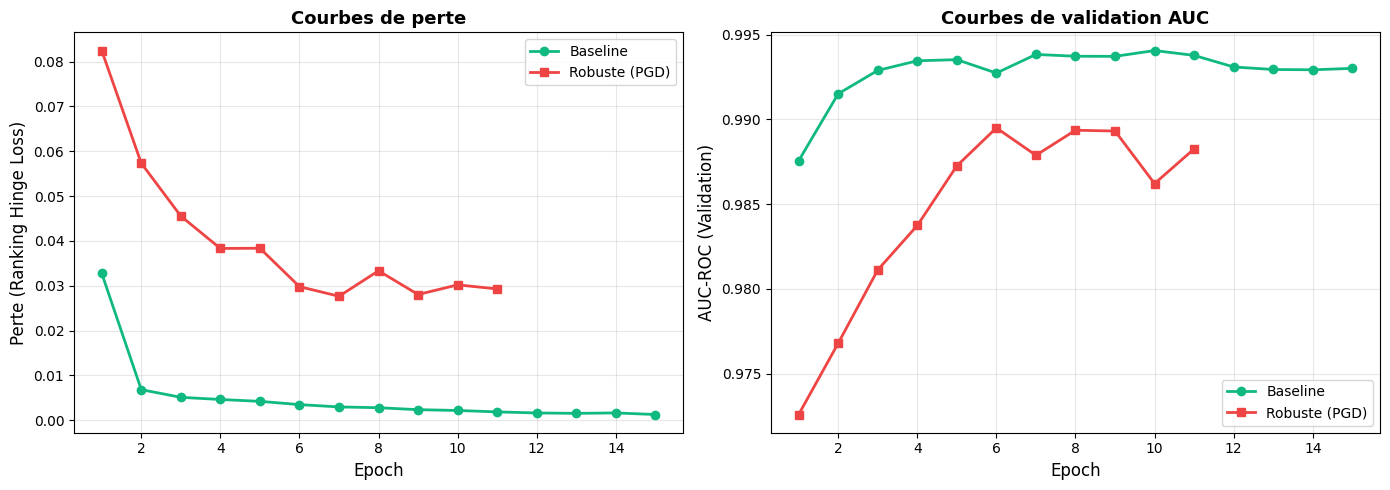


Baseline: AUC=0.9941 (epoch 15)
Robuste:  AUC=0.9895 (epoch 11)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline["epochs"], history_baseline["loss"], 
         marker='o', linewidth=2, label='Baseline', color='#10b981')
axes[0].plot(history_robust["epochs"], history_robust["loss"], 
         marker='s', linewidth=2, label='Robuste (PGD)', color='#ef4444')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Perte (Ranking Hinge Loss)', fontsize=12)
axes[0].set_title('Courbes de perte', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline["epochs"], history_baseline["val_auc"], 
         marker='o', linewidth=2, label='Baseline', color='#10b981')
axes[1].plot(history_robust["epochs"], history_robust["val_auc"], 
         marker='s', linewidth=2, label='Robuste (PGD)', color='#ef4444')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('AUC-ROC (Validation)', fontsize=12)
axes[1].set_title('Courbes de validation AUC', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBaseline: AUC={best_val_auc:.4f} (epoch {len(history_baseline['epochs'])})")
print(f"Robuste:  AUC={best_val_auc_pgd:.4f} (epoch {len(history_robust['epochs'])})")

### Selection du modele

Selection du meilleur modele basee sur AUC validation.

In [ ]:
print("\nEvaluation sur validation...")

metrics_baseline = evaluate_detector(detector_baseline, val_loader)
metrics_robust = evaluate_detector(detector_robust, val_loader)

print(f"Baseline - AUC: {metrics_baseline['auc']:.4f}, F1: {metrics_baseline['f1']:.4f}")
print(f"Robuste  - AUC: {metrics_robust['auc']:.4f}, F1: {metrics_robust['f1']:.4f}")

if metrics_baseline['auc'] >= metrics_robust['auc']:
    detector = detector_baseline
    selected_model = "BASELINE"
    best_metrics = metrics_baseline
else:
    detector = detector_robust
    selected_model = "ROBUSTE"
    best_metrics = metrics_robust

detector.eval()
torch.save(detector.state_dict(), str(WORKING_DIR / "detector_best.pth"))
print(f"\nModele selectionne: {selected_model} (AUC: {best_metrics['auc']:.4f})")



Evaluation sur validation...
Baseline - AUC: 0.9941, F1: 0.9627
Robuste  - AUC: 0.9895, F1: 0.9190

Modele selectionne: BASELINE (AUC: 0.9941)


## Phase 5 : Evaluation

**Metriques** : AUC-ROC, AP, Precision, Recall, F1, matrice de confusion

###  Fonctions d'inference

- `search_video()` : Recherche text-to-video
- `describe_video()` : Generation video-to-text
- `analyze_stream()` : Detection temporelle
- `evaluate_retrieval()` : Recall@K

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, average_precision_score

def get_text_from_database(idx):
    """Recupere le texte depuis text_database (gere ancien et nouveau format)."""
    if idx >= len(text_database):
        return "Unknown"
    entry = text_database[idx]
    if isinstance(entry, dict):
        return entry.get("text", str(entry))
    return str(entry)

def get_video_from_text_idx(idx):
    """Recupere le nom de video depuis l'index texte."""
    if idx >= len(text_database):
        return None
    entry = text_database[idx]
    if isinstance(entry, dict):
        return entry.get("video", None)
    return None

def search_video(query_text, k=5):
    with torch.no_grad():
        text_emb = tokenizer([query_text]).to(DEVICE)
        text_feat = model.encode_text(text_emb)
        text_feat = F.normalize(text_feat, p=2, dim=-1).cpu().numpy().astype('float32')
    D, I = index_video.search(text_feat, k)
    
    print(f"'{query_text}'")
    for i, (idx, score) in enumerate(zip(I[0], D[0]), 1):
        if idx < len(video_paths_list):
            video_name = Path(video_paths_list[idx]).name
            print(f"  {i}. {video_name} ({score:.3f})")
    print()
    return I[0], D[0]

def search_text(query_text, k=5):
    """Recherche semantique dans l'index texte (descriptions UCF)."""
    with torch.no_grad():
        text_emb = tokenizer([query_text]).to(DEVICE)
        text_feat = model.encode_text(text_emb)
        text_feat = F.normalize(text_feat, p=2, dim=-1).cpu().numpy().astype('float32')
    D, I = index_text.search(text_feat, k)
    
    results = []
    print(f"Recherche texte: '{query_text}'")
    for i, (idx, score) in enumerate(zip(I[0], D[0]), 1):
        text = get_text_from_database(idx)
        video = get_video_from_text_idx(idx)
        results.append({"video": video, "text": text, "score": float(score)})
        video_str = f"[{video}] " if video else ""
        print(f"  {i}. {video_str}({score:.3f}) {text[:60]}...")
    print()
    return results

def describe_video(video_path):
    feats = extract_video_features(video_path, model, preprocess)
    mean_feat = feats.mean(dim=0).cpu().numpy().astype('float32')
    faiss.normalize_L2(mean_feat.reshape(1, -1))
    D, I = index_text.search(mean_feat.reshape(1, -1), k=5)
    
    # Dedupliquer par video pour obtenir des descriptions variees
    seen_videos = set()
    results = []
    for idx, score in zip(I[0], D[0]):
        text = get_text_from_database(idx)
        video = get_video_from_text_idx(idx)
        
        # Eviter plusieurs phrases de la meme video
        if video and video in seen_videos:
            continue
        seen_videos.add(video)
        results.append({"video": video, "text": text, "score": float(score)})
        
        if len(results) >= 3:
            break
    
    print(f"{Path(video_path).name}")
    for i, r in enumerate(results, 1):
        print(f"  {i}. ({r['score']:.3f}) {r['text'][:80]}...")
    print()
    return results

def analyze_stream(features_seq, generate_description=False):
    detector.eval()
    with torch.no_grad():
        input_tensor = features_seq.unsqueeze(0).to(DEVICE)
        scores = detector(input_tensor)
    
    anomaly_scores = scores.squeeze().cpu().numpy()
    description = None
    
    if generate_description and anomaly_scores.max() > 0.5:
        mean_feat = features_seq.mean(dim=0).cpu().numpy().astype('float32')
        faiss.normalize_L2(mean_feat.reshape(1, -1))
        D, I = index_text.search(mean_feat.reshape(1, -1), k=1)
        
        if I[0][0] < len(text_database):
            description = get_text_from_database(I[0][0])
    
    return anomaly_scores, description

def evaluate_retrieval(queries, ground_truth_indices, k_values=[1, 5, 10]):
    recall_at_k = {k: [] for k in k_values}
    
    for query, gt_indices in zip(queries, ground_truth_indices):
        with torch.no_grad():
            text_emb = tokenizer([query]).to(DEVICE)
            text_feat = model.encode_text(text_emb)
            text_feat = F.normalize(text_feat, p=2, dim=-1).cpu().numpy().astype('float32')
        
        max_k = max(k_values)
        D, I = index_video.search(text_feat, max_k)
        retrieved = set(I[0])
        
        for k in k_values:
            top_k = set(I[0][:k])
            recall = len(top_k & set(gt_indices)) / len(gt_indices) if gt_indices else 0
            recall_at_k[k].append(recall)
    
    return {k: np.mean(v) for k, v in recall_at_k.items()}

### Test recherche text-to-video

In [ ]:
test_queries = [
    "A person stealing",
    "Car accident on the road",
    "People fighting in the street"
]

for query in test_queries:
    search_video(query, k=3)

'A person stealing'
  1. Fighting023_x264.mp4 (0.364)
  2. Normal_Videos322_x264.mp4 (0.358)
  3. Normal_Videos096_x264.mp4 (0.357)

'Car accident on the road'
  1. Explosion003_x264.mp4 (0.298)
  2. RoadAccidents085_x264.mp4 (0.291)
  3. RoadAccidents060_x264.mp4 (0.290)

'People fighting in the street'
  1. Fighting020_x264.mp4 (0.368)
  2. Fighting027_x264.mp4 (0.357)
  3. RoadAccidents110_x264.mp4 (0.350)



###  Dataset de test

In [ ]:
if 'all_annotations' not in dir():
    if 'all_datasets' in dir() and all_datasets:
        all_annotations = {**all_datasets.get("train", {}), **all_datasets.get("val", {}), **all_datasets.get("test", {})}
    else:
        all_annotations = {}

# Test uniquement sur UCF-Crime
test_dataset = MultiDatasetFeatureDataset(
    split='test',
    annotations_db=all_annotations,
    use_clip_labels=False,
    return_video_name=False,
    allowed_datasets=LSTM_ALLOWED_DATASETS
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn_mil)
print(f"Test: {len(test_dataset)} videos (UCF-Crime uniquement)")

Split test: 410 videos
  ucf_crime: 104 normal, 206 anomaly
  cadp: 53 normal, 47 anomaly
Test: 410 videos


###  Inference sur test set

In [ ]:
test_metrics = evaluate_detector(detector, test_loader)
all_scores = test_metrics['scores']
all_labels = test_metrics['labels']
print(f"Evaluation test: {len(all_scores)} videos ({int((all_labels == 1).sum())} anomalies)")

Evaluation test: 410 videos (253 anomalies)


###  Metriques de performance

In [ ]:
optimal_threshold = 0.4
all_predictions = (all_scores > optimal_threshold).astype(int)
cm = confusion_matrix(all_labels, all_predictions)

print(f"\nResultats test ({selected_model}):")
print(f"  AUC: {test_metrics['auc']:.4f} | AP: {test_metrics['ap']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f} | Recall: {test_metrics['recall']:.4f} | F1: {test_metrics['f1']:.4f}")
print(f"\nMatrice de confusion (seuil={optimal_threshold}):")
print(f"  VN={cm[0,0]} FP={cm[0,1]} | FN={cm[1,0]} VP={cm[1,1]}")


Resultats test (BASELINE):
  AUC: 0.8994 | AP: 0.9434
  Precision: 0.6941 | Recall: 0.9684 | F1: 0.8086

Matrice de confusion (seuil=0.4):
  VN=49 FP=108 | FN=8 VP=245


###  Courbe ROC

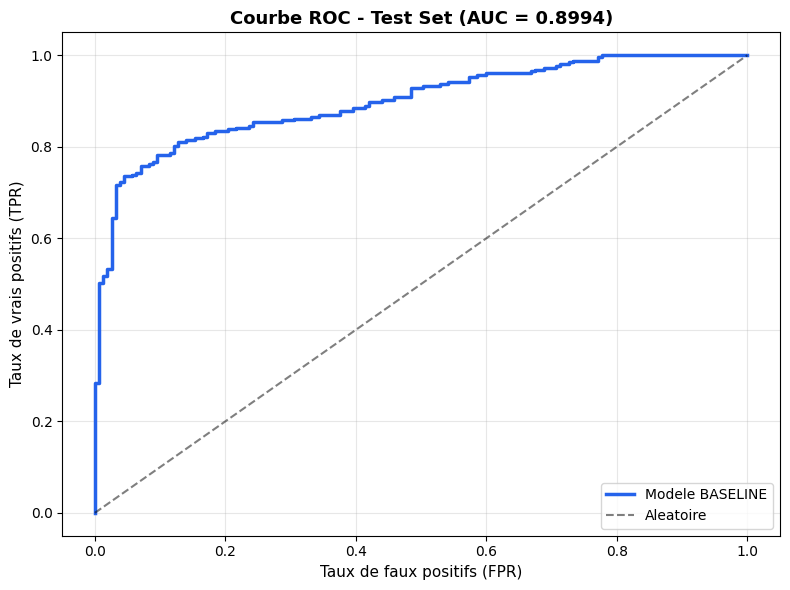

In [ ]:
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2.5, color='#2563eb', label=f'Modele {selected_model}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Aleatoire')
plt.xlabel('Taux de faux positifs (FPR)', fontsize=11)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=11)
plt.title(f'Courbe ROC - Test Set (AUC = {test_metrics["auc"]:.4f})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###  Distribution des scores

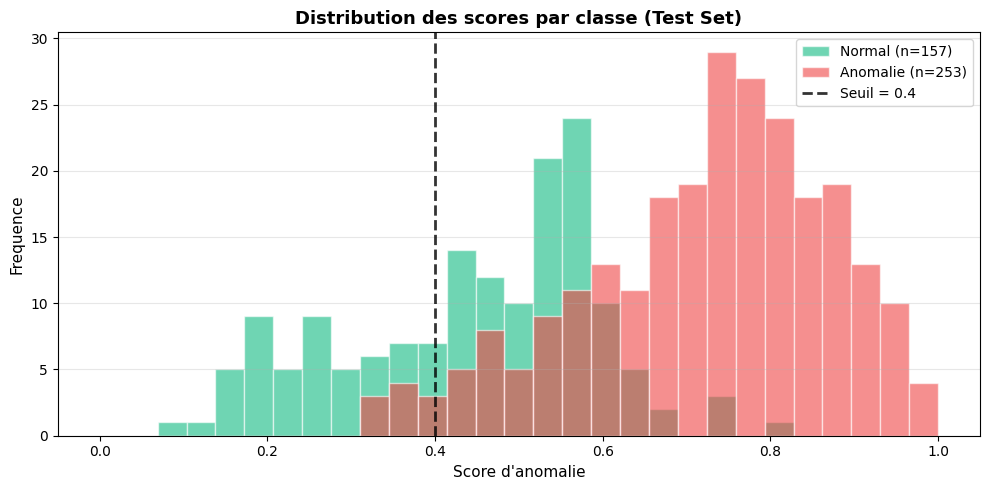

In [ ]:
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 1, 30)

plt.hist(all_scores[all_labels == 0], bins=bins, alpha=0.6, 
         label=f'Normal (n={int((all_labels == 0).sum())})', color='#10b981', edgecolor='white')
plt.hist(all_scores[all_labels == 1], bins=bins, alpha=0.6, 
         label=f'Anomalie (n={int((all_labels == 1).sum())})', color='#ef4444', edgecolor='white')
plt.axvline(optimal_threshold, color='black', linestyle='--', 
            linewidth=2, alpha=0.8, label=f'Seuil = {optimal_threshold}')

plt.xlabel('Score d\'anomalie', fontsize=11)
plt.ylabel('Frequence', fontsize=11)
plt.title('Distribution des scores par classe (Test Set)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Repartition par categorie

In [ ]:
if 'uca_test' in locals() and uca_test:
    anomaly_types = {}
    for fpath in test_dataset.files:
        video_name = fpath.stem
        anomaly_type = video_name.split('_')[0] if '_' in video_name else video_name
        anomaly_type = ''.join([c for c in anomaly_type if not c.isdigit()])
        if anomaly_type:
            if anomaly_type not in anomaly_types:
                anomaly_types[anomaly_type] = []
            anomaly_types[anomaly_type].append(video_name)
    
    print(f"Categories d'anomalies: {len(anomaly_types)}")
    sorted_types = sorted(anomaly_types.items(), key=lambda x: len(x[1]), reverse=True)
    for anom_type, videos in sorted_types[:10]:
        print(f"  {anom_type}: {len(videos)}")

Categories d'anomalies: 15
  Normal: 104
  cadp: 100
  RoadAccidents: 35
  Robbery: 28
  Burglary: 23
  Explosion: 23
  Arson: 19
  Assault: 14
  Stealing: 13
  Shooting: 12


## Phase 6 : Demonstration Gradio

Interface web interactive avec trois modules de demonstration.

### 6.1 Chargement du modele

In [ ]:
if 'detector' not in locals() or detector is None:
    best_model_path = WORKING_DIR / "detector_best.pth"
    if best_model_path.exists():
        detector = AnomalyDetector(input_dim=EMBED_DIM, hidden_dim=512).to(DEVICE)
        detector.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
        detector.eval()
        print(f"Modele charge: {best_model_path}")
    else:
        print("ERREUR: detector_best.pth introuvable")
else:
    print(f"Modele {selected_model if 'selected_model' in locals() else ''} pret")

Modele BASELINE pret


In [ ]:
try:
    import gradio as gr
except ImportError:
    print("Installation de Gradio...")
    import subprocess
    subprocess.check_call(["pip", "install", "-q", "gradio"])
    import gradio as gr

def convert_video_path(kaggle_path):
    if MODE == "LOCAL":
        path_str = str(kaggle_path)
        if path_str.startswith("/kaggle/input/"):
            local_path = path_str.replace("/kaggle/input/", "")
            return Path(local_path)
        return Path(path_str)
    return Path(kaggle_path)

def get_video_thumbnail(video_path, size=(320, 180)):
    """Extrait une thumbnail d'une video."""
    try:
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 3)
        ret, frame = cap.read()
        cap.release()
        
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            return Image.fromarray(frame)
    except:
        pass
    
    placeholder = Image.new('RGB', size, color=(40, 40, 40))
    return placeholder

def gradio_search_video(query_text, top_k):
    if not query_text.strip():
        return [], "Veuillez entrer une requete.", None
    
    try:
        indices, scores = search_video(query_text, k=int(top_k))
        
        gallery_items = []
        video_data = []
        
        for i, (idx, score) in enumerate(zip(indices, scores), 1):
            if idx < len(video_paths_list):
                original_path = video_paths_list[idx]
                local_path = convert_video_path(original_path)
                video_name = Path(original_path).stem
                
                if local_path.exists():
                    thumbnail = get_video_thumbnail(local_path)
                    caption = f"#{i} - {score:.3f}\n{video_name[:25]}"
                    gallery_items.append((thumbnail, caption))
                    video_data.append(str(local_path))
                else:
                    placeholder = Image.new('RGB', (320, 180), color=(60, 60, 60))
                    caption = f"#{i} - {score:.3f}\n{video_name[:25]} [N/A]"
                    gallery_items.append((placeholder, caption))
                    video_data.append(None)
        
        summary = f"Requete: \"{query_text}\"\nResultats: {len(gallery_items)} videos trouvees"
        
        best_video = next((v for v in video_data if v is not None), None)
        
        return gallery_items, summary, best_video
    
    except Exception as e:
        return [], f"Erreur: {str(e)}", None

def on_gallery_select(evt: gr.SelectData, gallery_data):
    """Callback quand l'utilisateur clique sur une thumbnail."""
    if evt.index is not None and gallery_data:
        indices, scores = gallery_data
        if evt.index < len(video_paths_list):
            original_path = video_paths_list[indices[evt.index]]
            local_path = convert_video_path(original_path)
            if local_path.exists():
                return str(local_path)
    return None

def gradio_analyze_video(video_file):
    if video_file is None:
        return "Aucune video fournie.", None
    
    cap = None
    try:
        video_path = Path(video_file)
        
        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = total_frames / fps if fps > 0 else 0
        cap.release()
        cap = None
        
        video_name = video_path.stem
        feat_path = WORKING_DIR / "video_embeddings" / f"{video_name}.pt"
        
        if feat_path.exists():
            features = torch.load(feat_path, map_location='cpu')
        else:
            features = extract_video_features(video_path, model, preprocess).cpu()
        
        # Analyser la video avec generation automatique de description
        anomaly_scores, anomaly_description = analyze_stream(features, generate_description=True)
        
        max_score = float(anomaly_scores.max())
        mean_score = float(anomaly_scores.mean())
        
        is_anomaly = max_score > 0.5
        verdict = "ANOMALIE DETECTEE" if is_anomaly else "COMPORTEMENT NORMAL"
        
        results_text = f"Video: {video_path.name}\n"
        results_text += f"Duree: {duration:.1f}s | Segments: {len(anomaly_scores)}\n\n"
        results_text += f"Verdict: {verdict}\n"
        results_text += f"Score max: {max_score:.4f} | Score moyen: {mean_score:.4f}\n"
        
        if is_anomaly:
            peak_segment = int(anomaly_scores.argmax())
            peak_time = (peak_segment / len(anomaly_scores)) * duration
            results_text += f"Pic d'anomalie: segment {peak_segment} (~{peak_time:.1f}s)\n\n"
            
            # Ajouter la description automatique de l'anomalie
            if anomaly_description:
                results_text += f"Description de l'anomalie:\n{anomaly_description[:200]}..."
        
        fig = plt.figure(figsize=(12, 4))
        time_axis = np.linspace(0, duration, len(anomaly_scores))
        plt.plot(time_axis, anomaly_scores, linewidth=2, color='#2563eb')
        plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Seuil')
        plt.fill_between(time_axis, 0, anomaly_scores, alpha=0.3, color='#2563eb')
        plt.xlabel('Temps (secondes)', fontsize=11)
        plt.ylabel('Score d\'anomalie', fontsize=11)
        plt.title('Evolution temporelle du score d\'anomalie', fontsize=13, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        return results_text, fig
    
    except Exception as e:
        return f"Erreur lors de l'analyse: {str(e)}", None
    
    finally:
        if cap is not None:
            cap.release()

def gradio_describe_video(video_file):
    if video_file is None:
        return "Aucune video fournie."
    
    try:
        video_path = Path(video_file)
        results = describe_video(video_path)
        
        output_text = f"Video: {video_path.name}\n\n"
        
        for i, (desc, score) in enumerate(results, 1):
            output_text += f"{i}. (similarite: {score:.3f})\n{desc}\n\n"
        
        return output_text
    
    except Exception as e:
        return f"Erreur: {str(e)}"

custom_css = """
#main-title {
    text-align: center;
    font-size: 2.2rem;
    font-weight: 700;
    margin-bottom: 0.5rem;
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}
#subtitle {
    text-align: center;
    font-size: 1rem;
    color: #6b7280;
    margin-bottom: 1.5rem;
}
.gallery-item {
    border-radius: 12px !important;
    overflow: hidden;
    transition: transform 0.2s ease;
}
.gallery-item:hover {
    transform: scale(1.03);
    box-shadow: 0 8px 25px rgba(0,0,0,0.15);
}
#search-gallery {
    min-height: 250px;
}
#search-gallery .caption {
    font-size: 0.9rem;
    font-weight: 600;
    text-align: center;
    padding: 8px;
    background: linear-gradient(180deg, transparent 0%, rgba(0,0,0,0.7) 100%);
    color: white;
}
.result-summary {
    font-size: 1.1rem;
    font-weight: 500;
    padding: 12px;
    background: #f0f9ff;
    border-left: 4px solid #2563eb;
    border-radius: 0 8px 8px 0;
}
#output-box {
    font-family: 'SF Mono', Monaco, 'Cascadia Code', monospace;
    background: #f9fafb;
    border-radius: 8px;
    padding: 1rem;
    font-size: 0.95rem;
}
.primary-btn {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
    border: none !important;
    font-weight: 600 !important;
}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    gr.Markdown("<h1 id='main-title'>Systeme de Surveillance Vision-Language</h1>")
    gr.Markdown("<p id='subtitle'>Detection d'anomalies et recherche semantique | OpenCLIP + FAISS + MIL-PGD</p>")
    
    search_state = gr.State(None)
    
    with gr.Tabs():
        with gr.Tab("Recherche Video"):
            with gr.Row():
                with gr.Column(scale=1):
                    search_input = gr.Textbox(
                        label="Requete de recherche",
                        placeholder="Ex: A person stealing a bag, car accident, people fighting...",
                        lines=2
                    )
                    search_k = gr.Slider(
                        minimum=1, maximum=10, value=5, step=1,
                        label="Nombre de resultats"
                    )
                    search_btn = gr.Button("Rechercher", variant="primary", size="lg", elem_classes="primary-btn")
                    search_summary = gr.Textbox(label="Resume", lines=2, elem_classes="result-summary")
                
                with gr.Column(scale=2):
                    search_gallery = gr.Gallery(
                        label="Resultats de recherche",
                        show_label=True,
                        elem_id="search-gallery",
                        columns=3,
                        rows=2,
                        height="auto",
                        object_fit="cover",
                        allow_preview=False
                    )
            
            with gr.Row():
                selected_video = gr.Video(label="Video selectionnee", height=400)
            
            def search_and_store(query, k):
                gallery, summary, best = gradio_search_video(query, k)
                indices, scores = search_video(query, k=int(k))
                return gallery, summary, best, (indices, scores)
            
            search_btn.click(
                fn=search_and_store,
                inputs=[search_input, search_k],
                outputs=[search_gallery, search_summary, selected_video, search_state]
            )
            
            def select_video(evt: gr.SelectData, state):
                if state is None:
                    return None
                indices, scores = state
                if evt.index < len(indices):
                    idx = indices[evt.index]
                    if idx < len(video_paths_list):
                        local_path = convert_video_path(video_paths_list[idx])
                        if local_path.exists():
                            return str(local_path)
                return None
            
            search_gallery.select(
                fn=select_video,
                inputs=[search_state],
                outputs=[selected_video]
            )
        
        with gr.Tab("Analyse Video"):
            with gr.Row():
                with gr.Column(scale=1):
                    video_input = gr.Video(label="Charger une video")
                    analyze_btn = gr.Button("Analyser", variant="primary", size="lg", elem_classes="primary-btn")
                
                with gr.Column(scale=2):
                    analyze_output = gr.Textbox(label="Rapport", lines=6, elem_id="output-box")
                    analyze_plot = gr.Plot(label="Scores temporels")
            
            analyze_btn.click(
                fn=gradio_analyze_video,
                inputs=[video_input],
                outputs=[analyze_output, analyze_plot]
            )
        
        with gr.Tab("Description Video"):
            with gr.Row():
                with gr.Column(scale=1):
                    desc_video_input = gr.Video(label="Charger une video")
                    describe_btn = gr.Button("Generer", variant="primary", size="lg", elem_classes="primary-btn")
                
                with gr.Column(scale=2):
                    desc_output = gr.Textbox(label="Descriptions generees", lines=12, elem_id="output-box")
            
            describe_btn.click(
                fn=gradio_describe_video,
                inputs=[desc_video_input],
                outputs=[desc_output]
            )
    
    gr.Markdown("---\n**Mode:** " + MODE + " | **Modele:** OpenCLIP ViT-L-14 | **Index:** " + str(index_video.ntotal) + " videos")

print("Lancement de l'interface Gradio...")

# Fermer l'instance precedente si elle existe
try:
    if 'demo' in globals():
        demo.close()
        print("Instance precedente fermee.")
except Exception as e:
    print(f"Avertissement lors de la fermeture: {e}")

demo.launch(prevent_thread_lock=True)

Lancement de l'interface Gradio...
Instance precedente fermee.
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


### Conclusion

Nous avons essayé de mettre en place une architecture qui ne se contente pas de traiter des pixels, mais qui tente de comprendre le contexte via des modèles Vision-Langage. L'idée centrale était de combiner la richesse sémantique des embeddings d'OpenCLIP avec la capacité temporelle d'un LSTM bidirectionnel. Une étape intéressante a été l'utilisation en amont d'un Small Language Model (Qwen2.5) pour convertir des métadonnées techniques en vraies descriptions, ce qui nous a permis de voir comment on peut enrichir artificiellement un dataset pour préparer un alignement image-texte.
Cependant, notre architecture a été clairement bridée par les limitations matérielles de Colab et Kaggle. Nous avions implémenté toute la logique pour fine-tuner l'encodeur visuel avec LoRA, mais la mémoire GPU était insuffisante pour gérer la rétropropagation sur un modèle aussi lourd que le ViT-L-14. Nous avons donc dû utiliser les poids de base d'OpenCLIP (entraînés sur des images généralistes).

Si nous avions pu spécialiser les embeddings pour la vidéosurveillance, la séparation entre les vecteurs "normaux" et "anormaux" aurait été bien plus nette, ce qui aurait facilité la tâche du LSTM et réduit le nombre de fausses alarmes que l'on observe actuellement.

Malgré cet obstacle, l'approche par apprentissage faiblement supervisé s'est révélée efficace. Le fait d'utiliser une Ranking Hinge Loss a forcé le modèle à repérer les segments les plus saillants sans jamais avoir besoin de timestamps précis, ce qui est assez puissant vu la difficulté d'annoter des vidéos frame par frame. Au final, même avec des features non spécialisées, le fait d'unifier plusieurs sources de données (vidéos et images) et de coupler le tout à un index FAISS permet d'obtenir un système qui détecte bien les anomalies (97% de rappel) et qui offre surtout une couche d'explication textuelle, ce qui manque souvent aux détecteurs classiques.